# Frame Detection — Results Analysis & Visualization

This notebook analyzes the output of the frame-detection pipeline (`framing_chat_6_frames_events_revised_v7.ipynb`)
across one or more models. It is designed to work directly with the flattened CSV outputs produced by that
pipeline (`frames_<dataset_stem>_<model_slug>.csv`), including:

- The single-model run outputs in `./data/`
- The multi-model comparison outputs in `./data/frame_model_comparison/<model_slug>/`

It produces:

1. **Comparative statistics on `frame_label`** (NOT_FRAMED / SINGLE_FRAME / MULTIPLE_FRAMES) across models.
2. **Detailed and aggregate statistics on `frame_type`** (the 12 frame×polarity categories), per model and across
   models.
3. **Positive vs. negative polarity visualizations** for each of the 6 substantive frames.
4. **Frame type over time, by model**, including a polarity × time view (polarity on one axis, time on the other),
   provided a date-like column is available in the input data.

Nothing here re-runs the LLM — it only reads and analyzes the CSVs already produced.


## Configuration

Edit `DATA_DIR` / `EXTRA_PATHS` if your outputs live somewhere else. By default this notebook auto-discovers
every `frames_*.csv` file under `DATA_DIR` (single-model runs) and under
`DATA_DIR/frame_model_comparison/*/` (the model-comparison run), then combines them.

If you'd rather point at specific files/models explicitly, set `MANUAL_FILES` to a dict of
`{model_name: path_to_csv}` and it will be used instead of auto-discovery.


In [1]:

import glob
import json
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.0)

# --- Frame taxonomy (must match the detection notebook) ---------------------
FRAME_NAMES = ["modernization", "patriotism", "victimhood", "moral", "economic", "diplomacy"]
POLARITIES = ["positive", "negative"]
FRAME_TYPE_ORDER = [f"{f} ({p})" for f in FRAME_NAMES for p in POLARITIES]
FRAME_LABEL_ORDER = ["NOT_FRAMED", "SINGLE_FRAME", "MULTIPLE_FRAMES"]

# --- Where to look for outputs -----------------------------------------------
DATA_DIR = Path("./data")

# Optional: bypass auto-discovery entirely by filling this in, e.g.
# MANUAL_FILES = {
#     "qwen3.5:35b": "./data/frames_sample_relevant_qwen3.5_35b.csv",
#     "llama3.3:70b": "./data/frame_model_comparison/llama3.3_70b/frames_sample_relevant_llama3.3_70b.csv",
# }
MANUAL_FILES: dict[str, str] = {}

print(f"Data directory: {DATA_DIR.resolve()}")


Data directory: /Users/carmand/Desktop/v24/framing_optimized/output/data


In [2]:

def discover_frame_csvs(data_dir: Path) -> list[Path]:
    # Find flattened frame-detection CSVs: single-model runs directly under
    # data_dir, and per-model runs under data_dir/frame_model_comparison/*/.
    patterns = [
        str(data_dir / "frames_*.csv"),
        str(data_dir / "frame_model_comparison" / "*" / "frames_*.csv"),
        str(data_dir / "frame_model_comparison" / "*" / "*.csv"),
    ]
    found: list[Path] = []
    for pat in patterns:
        found.extend(Path(p) for p in glob.glob(pat))
    # de-duplicate while preserving order
    seen = set()
    unique = []
    for p in found:
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            unique.append(p)
    return sorted(unique)


if MANUAL_FILES:
    discovered = [Path(p) for p in MANUAL_FILES.values()]
    print("Using MANUAL_FILES:")
    for model, p in MANUAL_FILES.items():
        print(f"  {model}: {p}")
else:
    discovered = discover_frame_csvs(DATA_DIR)
    print(f"Discovered {len(discovered)} CSV file(s):")
    for p in discovered:
        print(" ", p)

assert discovered, (
    "No frame-detection CSVs found. Point DATA_DIR at the right folder, "
    "or fill in MANUAL_FILES explicitly."
)


Discovered 2 CSV file(s):
  data/frames_debate_complete_gemma3_27b.csv
  data/frames_debate_complete_qwen3.5_35b.csv


## Load, clean, and reshape

Each row of a flattened output CSV represents one segment as scored by one model. `frame_type` is a
`|`-joined string like `"patriotism (positive)|economic (negative)"` (empty when `NOT_FRAMED`).

We:
- load every discovered CSV and tag it with its model (from `framing_model`, falling back to the file/folder name),
- drop rows flagged with `frame_processing_error == TRUE` (failed LLM calls carry no usable label),
- try to detect a date-like column so we can do the time-based analysis in Section 5,
- build a **long-format** table (`exploded`) with one row per *(segment, frame_type)* pair, splitting
  `frame_type` into `frame_name` + `polarity`, which is what most of the plots below use.


In [3]:

def model_name_from_path(path: Path) -> str:
    # e.g. .../frame_model_comparison/llama3.3_70b/frames_..._llama3.3_70b.csv -> "llama3.3_70b"
    if path.parent.name and path.parent.name != DATA_DIR.name:
        return path.parent.name
    m = re.search(r"frames_.+?_([A-Za-z0-9._-]+)\.csv$", path.name)
    return m.group(1) if m else path.stem


frames = []
for p in discovered:
    d = pd.read_csv(p, keep_default_na=False, dtype=str)
    d["_source_file"] = str(p)
    frames.append(d)

raw = pd.concat(frames, ignore_index=True, sort=False)
print(f"Loaded {len(raw):,} rows total across {len(discovered)} file(s).")
print("Columns:", list(raw.columns))

# Prefer the model recorded by the pipeline itself; fall back to path-derived name.
if "framing_model" in raw.columns and raw["framing_model"].str.strip().ne("").any():
    raw["model"] = raw["framing_model"].where(
        raw["framing_model"].str.strip().ne(""),
        raw["_source_file"].apply(lambda s: model_name_from_path(Path(s))),
    )
else:
    raw["model"] = raw["_source_file"].apply(lambda s: model_name_from_path(Path(s)))

print("\\nRows per model (before filtering errors):")
print(raw["model"].value_counts())


Loaded 9,268 rows total across 2 file(s).
Columns: ['Unnamed: 0', 'doc_id', 'date', 'title', 'source', 'segmentation_label', 'segmentation_confidence', 'segmentation_explanation', 'processing_error', 'segment_index', 'segment_text', 'segment_verbatim', 'topic_type', 'topic_policy', 'topic_debate', 'topic_biography', 'topic_organization', 'topic_other', 'relevance_to_original_topic', 'relevance_evidence', 'gender_mentioned', 'gender_evidence', 'year', '_input_row_number', '_row_id', 'frame_label', 'frame_type', 'frame_explanation', 'frame_evidence', 'frame_evidence_grounded', 'frame_evidence_error', 'framing_actors', 'framed_actors', 'framed_events', 'framing_confidence', 'frame_processing_error', 'frame_processing_error_type', 'framing_model', '_source_file']
\nRows per model (before filtering errors):
model
gemma3:27b     4634
qwen3.5:35b    4634
Name: count, dtype: int64


In [4]:

# Drop rows where the LLM call itself failed — no usable frame_label/frame_type.
if "frame_processing_error" in raw.columns:
    is_error = raw["frame_processing_error"].astype(str).str.upper().eq("TRUE")
    n_err = int(is_error.sum())
    ok = raw.loc[~is_error].copy()
    print(f"Dropped {n_err:,} row(s) with frame_processing_error=TRUE.")
else:
    ok = raw.copy()

# Numeric confidence.
if "framing_confidence" in ok.columns:
    ok["framing_confidence"] = pd.to_numeric(ok["framing_confidence"], errors="coerce")

# Normalize frame_label to the expected categorical order (unexpected/blank -> keep as-is, shown separately).
ok["frame_label"] = ok["frame_label"].astype(str).str.strip()

print(f"\\nUsable rows: {len(ok):,}")
print(ok["frame_label"].value_counts())


Dropped 13 row(s) with frame_processing_error=TRUE.
\nUsable rows: 9,255
frame_label
MULTIPLE_FRAMES    7038
SINGLE_FRAME       1762
NOT_FRAMED          455
Name: count, dtype: int64


In [ ]:
# --- Try to find a date-like column for the time-series analysis (Section 5) ---
DATE_COLUMN_CANDIDATES = [
    "date", "pub_date", "publish_date", "publication_date",
    "article_date", "issue_date", "issue", "year",
]

date_col = next((c for c in DATE_COLUMN_CANDIDATES if c in ok.columns), None)

if date_col == "year":
    ok["_date"] = pd.to_datetime(ok["year"], format="%Y", errors="coerce")
elif date_col is not None:
    ok["_date"] = pd.to_datetime(ok[date_col], errors="coerce")
else:
    ok["_date"] = pd.NaT

ok["_year"] = ok["_date"].dt.year
n_dated = ok["_year"].notna().sum()

if date_col is None:
    print("No date-like column found among:", DATE_COLUMN_CANDIDATES)
    print("Section 5 (frame type over time) will be skipped / shown as unavailable.")
else:
    print(f"Using '{date_col}' as the date column; parsed {n_dated:,}/{len(ok):,} rows successfully.")


Using 'date' as the date column; parsed 9,255/9,255 rows successfully.


In [6]:

# --- Long format: one row per (segment, frame_type) pair -------------------
ok["frame_type"] = ok["frame_type"].fillna("").astype(str)

exploded = ok.assign(frame_type_single=ok["frame_type"].str.split("|")).explode("frame_type_single")
exploded["frame_type_single"] = exploded["frame_type_single"].str.strip()
exploded = exploded[exploded["frame_type_single"] != ""].copy()


def split_frame_polarity(value: str):
    m = re.match(r"^(.*)\s\((positive|negative)\)$", value)
    return (m.group(1), m.group(2)) if m else (value, None)


_split = exploded["frame_type_single"].apply(split_frame_polarity)
exploded["frame_name"] = _split.apply(lambda t: t[0])
exploded["polarity"] = _split.apply(lambda t: t[1])

# Keep a tidy, ordered categorical for nicer plots/tables.
exploded["frame_name"] = pd.Categorical(exploded["frame_name"], categories=FRAME_NAMES, ordered=True)
exploded["polarity"] = pd.Categorical(exploded["polarity"], categories=POLARITIES, ordered=True)

MODEL_ORDER = sorted(ok["model"].unique())
ok["model"] = pd.Categorical(ok["model"], categories=MODEL_ORDER, ordered=True)
exploded["model"] = pd.Categorical(exploded["model"], categories=MODEL_ORDER, ordered=True)

print(f"Exploded table: {len(exploded):,} (segment, frame_type) rows across {len(MODEL_ORDER)} model(s): {MODEL_ORDER}")
exploded[["model", "frame_type_single", "frame_name", "polarity"]].head()


Exploded table: 21,686 (segment, frame_type) rows across 2 model(s): ['gemma3:27b', 'qwen3.5:35b']


,model,frame_type_single,frame_name,polarity
0,gemma3:27b,patriotism (positive),patriotism,positive
1,gemma3:27b,modernization (negative),modernization,negative
1,gemma3:27b,victimhood (positive),victimhood,positive
1,gemma3:27b,economic (negative),economic,negative
2,gemma3:27b,modernization (negative),modernization,negative


## Frame detection — comparative statistics across models

`frame_label` is the coarse count category per segment: `NOT_FRAMED`, `SINGLE_FRAME`, or `MULTIPLE_FRAMES`.


In [7]:

label_counts = (
    ok.groupby(["model", "frame_label"], observed=True)
      .size()
      .unstack(fill_value=0)
      .reindex(columns=FRAME_LABEL_ORDER, fill_value=0)
      .reindex(MODEL_ORDER)
)
label_props = label_counts.div(label_counts.sum(axis=1), axis=0)

print("Counts:")
display(label_counts)
print("\\nRow-wise proportions:")
display(label_props.round(3))


Counts:


frame_label,NOT_FRAMED,SINGLE_FRAME,MULTIPLE_FRAMES
model,,,
gemma3:27b,71,477,4080
qwen3.5:35b,384,1285,2958


\nRow-wise proportions:


frame_label,NOT_FRAMED,SINGLE_FRAME,MULTIPLE_FRAMES
model,,,
gemma3:27b,0.015,0.103,0.882
qwen3.5:35b,0.083,0.278,0.639


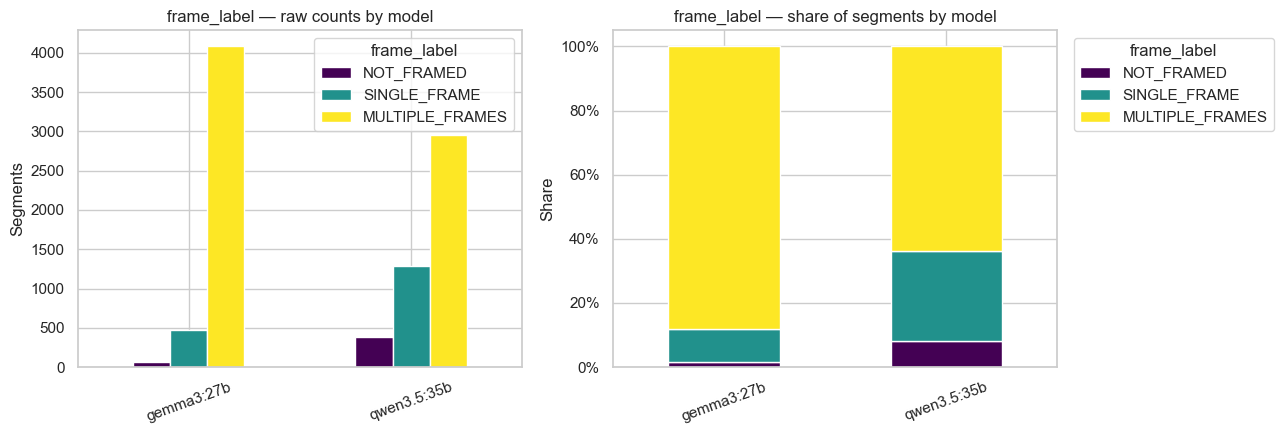

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

label_counts.plot(kind="bar", ax=axes[0], colormap="viridis", edgecolor="white")
axes[0].set_title("frame_label — raw counts by model")
axes[0].set_ylabel("Segments")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="frame_label")

label_props.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis", edgecolor="white")
axes[1].set_title("frame_label — share of segments by model")
axes[1].set_ylabel("Share")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="frame_label", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [9]:

# Pairwise agreement on frame_label for segments scored by >=2 models (only meaningful
# when the same _row_id was scored by multiple models, e.g. the model-comparison run).
if "_row_id" in ok.columns and ok["model"].nunique() > 1:
    pivot = ok.pivot_table(index="_row_id", columns="model", values="frame_label", aggfunc="first", observed=True)
    common = pivot.dropna()
    if len(common) > 0:
        agree = common.nunique(axis=1) == 1
        print(f"Segments scored by all {pivot.shape[1]} model(s): {len(common):,}")
        print(f"Exact frame_label agreement across all models: {agree.mean():.1%}")
    else:
        print("No segments were scored by all models (models were likely run on different rows) — skipping agreement check.")
else:
    print("Only one model present (or no _row_id column) — skipping cross-model agreement check.")


Segments scored by all 2 model(s): 4,621
Exact frame_label agreement across all models: 71.0%


## Frame classification (1) — detailed and aggregate statistics

Each substantive `frame_type` is one of the 12 frame × polarity combinations. A segment can contribute to more
than one `frame_type` (when `frame_label == MULTIPLE_FRAMES`), so counts here are **frame-type incidences**,
not segment counts.


In [14]:

# --- Detailed: per-model frame_type counts & shares -------------------------
type_counts = (
    exploded.groupby(["model", "frame_type_single"], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(columns=FRAME_TYPE_ORDER, fill_value=0)
            .reindex(MODEL_ORDER)
)

# Share of each model's own frame-type incidences (columns sum to 1 within a model... 
# here we show share of that model's total incidences, i.e. rows sum to 1).
type_shares = type_counts.div(type_counts.sum(axis=1), axis=0) * 100

print("frame_type counts by model:")
display(type_counts)
print("\\nframe_type shares by model (of that model's own frame-type incidences):")
display(type_shares.round(3))


frame_type counts by model:


frame_type_single,modernization (positive),modernization (negative),patriotism (positive),patriotism (negative),victimhood (positive),victimhood (negative),moral (positive),moral (negative),economic (positive),economic (negative),diplomacy (positive),diplomacy (negative)
model,,,,,,,,,,,,
gemma3:27b,1132,1910,1130,99,1476,12,327,2161,229,3192,940,1237
qwen3.5:35b,826,869,1476,456,711,1,80,1926,20,846,261,369


\nframe_type shares by model (of that model's own frame-type incidences):


frame_type_single,modernization (positive),modernization (negative),patriotism (positive),patriotism (negative),victimhood (positive),victimhood (negative),moral (positive),moral (negative),economic (positive),economic (negative),diplomacy (positive),diplomacy (negative)
model,,,,,,,,,,,,
gemma3:27b,8.176,13.796,8.162,0.715,10.661,0.087,2.362,15.609,1.654,23.055,6.789,8.935
qwen3.5:35b,10.534,11.083,18.824,5.816,9.068,0.013,1.020,24.563,0.255,10.789,3.329,4.706


In [16]:

# --- Aggregate: across all models combined ----------------------------------
type_counts_agg = (
    exploded.groupby("frame_type_single", observed=True)
            .size()
            .reindex(FRAME_TYPE_ORDER, fill_value=0)
            .rename("count")
            .to_frame()
)
type_counts_agg["share"] = type_counts_agg["count"] / type_counts_agg["count"].sum() * 100

print("frame_type counts aggregated across all models:")
display(type_counts_agg.sort_values("count", ascending=False).round({"share": 3}))


frame_type counts aggregated across all models:


,count,share
frame_type_single,,
moral (negative),4087,18.846
economic (negative),4038,18.620
modernization (negative),2779,12.815
patriotism (positive),2606,12.017
victimhood (positive),2187,10.085
modernization (positive),1958,9.029
diplomacy (negative),1606,7.406
diplomacy (positive),1201,5.538
patriotism (negative),555,2.559


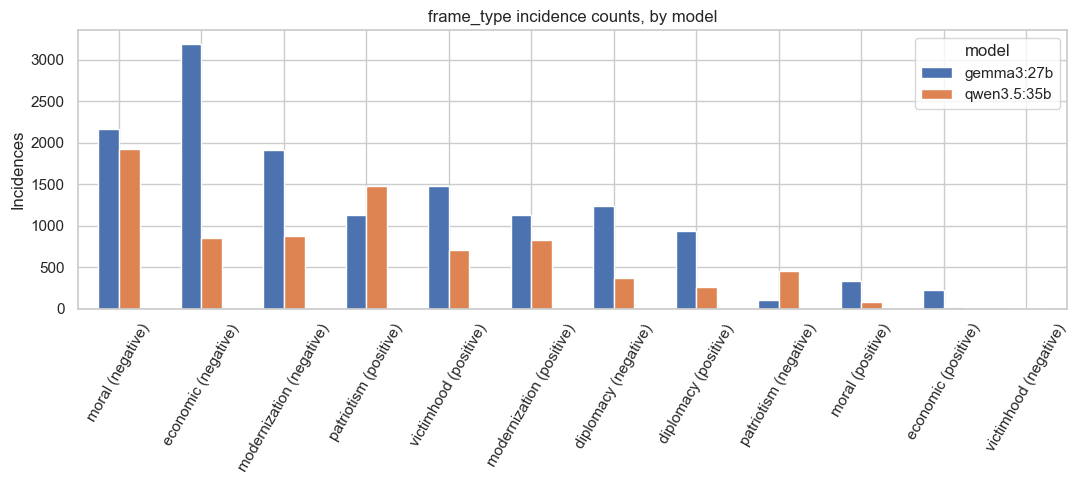

In [17]:

fig, ax = plt.subplots(figsize=(11, 5))
order = type_counts_agg.sort_values("count", ascending=False).index
type_counts.T.reindex(order).plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("frame_type incidence counts, by model")
ax.set_ylabel("Incidences")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=60)
ax.legend(title="model")
plt.tight_layout()
plt.show()


Let's visualize the results as a heatmap (matrix) of frame_type × model, with counts in each cell. This is a more compact way to see the same information as the bar chart above.

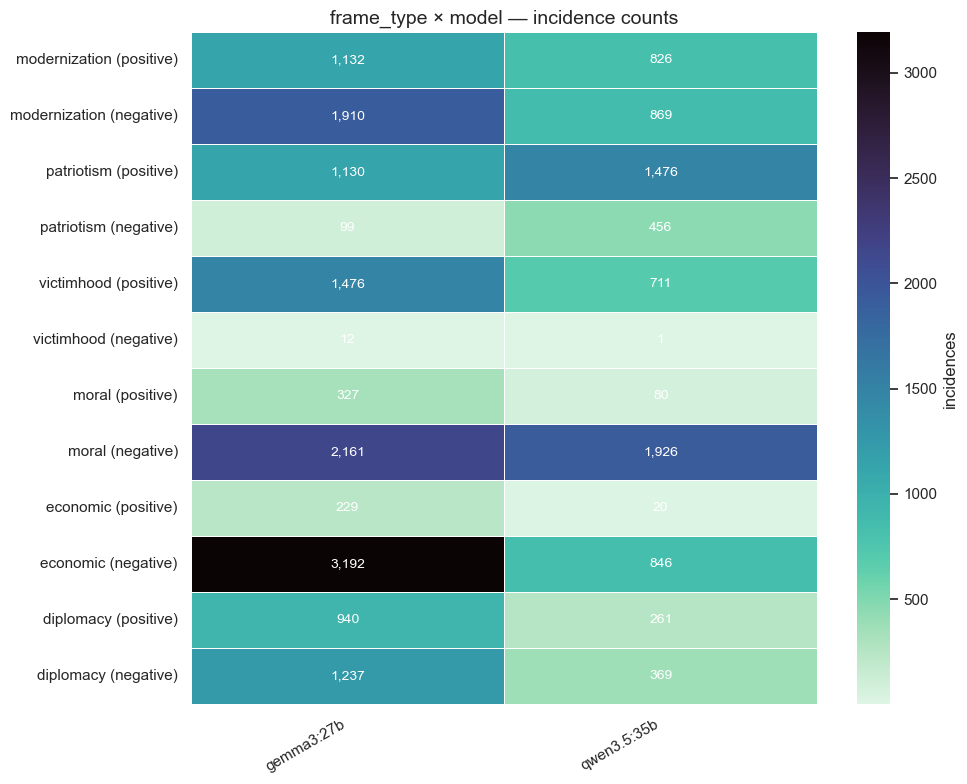

In [42]:

plot_data = (
    type_counts
    .T
    .reindex(FRAME_TYPE_ORDER)
    .reindex(columns=MODEL_ORDER)
    .fillna(0)
    .astype(int)
)

# Much wider figure
fig, ax = plt.subplots(
    figsize=(5 * len(plot_data.columns), 8)
)

# Draw heatmap WITHOUT seaborn annotations
sns.heatmap(
    plot_data,
    annot=False,
    cmap="mako_r",
    cbar_kws={"label": "incidences"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

# Manually add value to EVERY cell
for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        value = plot_data.iloc[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:,}",       # e.g. 3,192
            ha="center",
            va="center",
            fontsize=10,
            color="white",
        )

ax.set_title("frame_type × model — incidence counts", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("")

# X-axis model names
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

# Keep all y-axis labels visible
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

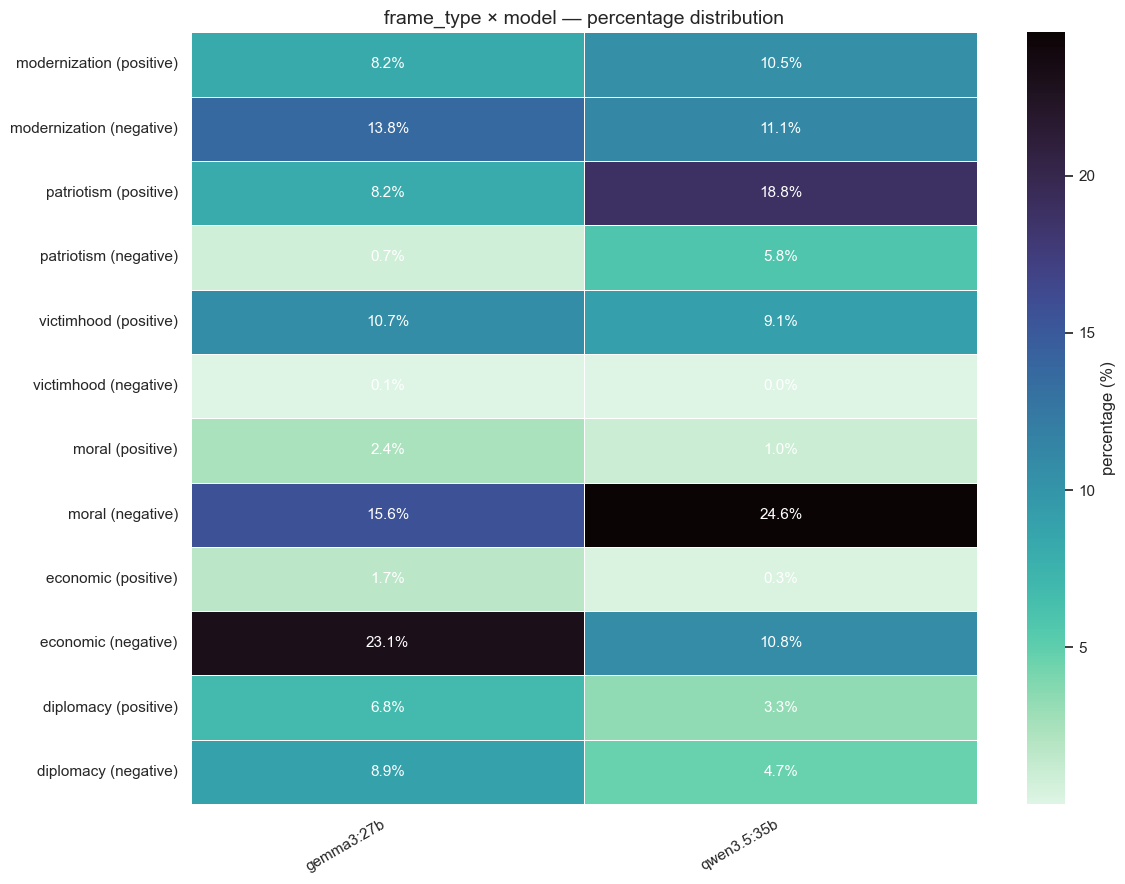

In [39]:
# Build the heatmap with percentages instead of raw counts

plot_data = (
    type_counts
    .T
    .reindex(FRAME_TYPE_ORDER)
    .reindex(columns=MODEL_ORDER)
    .fillna(0)
)

# Percentage within each model column
plot_pct = plot_data.div(plot_data.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(
    figsize=(6 * len(plot_pct.columns), 9)
)

# Draw heatmap without automatic annotations
sns.heatmap(
    plot_pct,
    annot=False,
    cmap="mako_r",
    cbar_kws={"label": "percentage (%)"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

# Manually write percentage in every cell
for i in range(plot_pct.shape[0]):
    for j in range(plot_pct.shape[1]):
        value = plot_pct.iloc[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=11,
            color="white",
            clip_on=False,
        )

ax.set_title("frame_type × model — percentage distribution", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

## Frame classification (2) — detailed and aggregate statistics

In [33]:
# --- Detailed: per-model frame_name counts & shares -------------------------
name_counts = (
    exploded.groupby(["model", "frame_name"], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(columns=FRAME_NAMES, fill_value=0)
            .reindex(MODEL_ORDER)
)

# Share of each model's own frame-name incidences (columns sum to 1 within a model... 
# here we show share of that model's total incidences, i.e. rows sum to 1).
name_shares = name_counts.div(name_counts.sum(axis=1), axis=0) * 100

print("frame_name counts by model:")
display(name_counts)
print("\\nframe_name shares by model (of that model's own frame-name incidences):")
display(name_shares.round(3))

frame_name counts by model:


frame_name,modernization,patriotism,victimhood,moral,economic,diplomacy
model,,,,,,
gemma3:27b,3042,1229,1488,2488,3421,2177
qwen3.5:35b,1695,1932,712,2006,866,630


\nframe_name shares by model (of that model's own frame-name incidences):


frame_name,modernization,patriotism,victimhood,moral,economic,diplomacy
model,,,,,,
gemma3:27b,21.972,8.877,10.748,17.970,24.709,15.724
qwen3.5:35b,21.617,24.640,9.080,25.583,11.045,8.035


In [34]:

# --- Aggregate: across all models combined ----------------------------------
name_counts_agg = (
    exploded.groupby("frame_name", observed=True)
            .size()
            .reindex(FRAME_NAMES, fill_value=0)
            .rename("count")
            .to_frame()
)
name_counts_agg["share"] = name_counts_agg["count"] / name_counts_agg["count"].sum() * 100

print("frame_name counts aggregated across all models:")
display(name_counts_agg.sort_values("count", ascending=False).round({"share": 3}))


frame_name counts aggregated across all models:


,count,share
frame_name,,
modernization,4737,21.844
moral,4494,20.723
economic,4287,19.769
patriotism,3161,14.576
diplomacy,2807,12.944
victimhood,2200,10.145


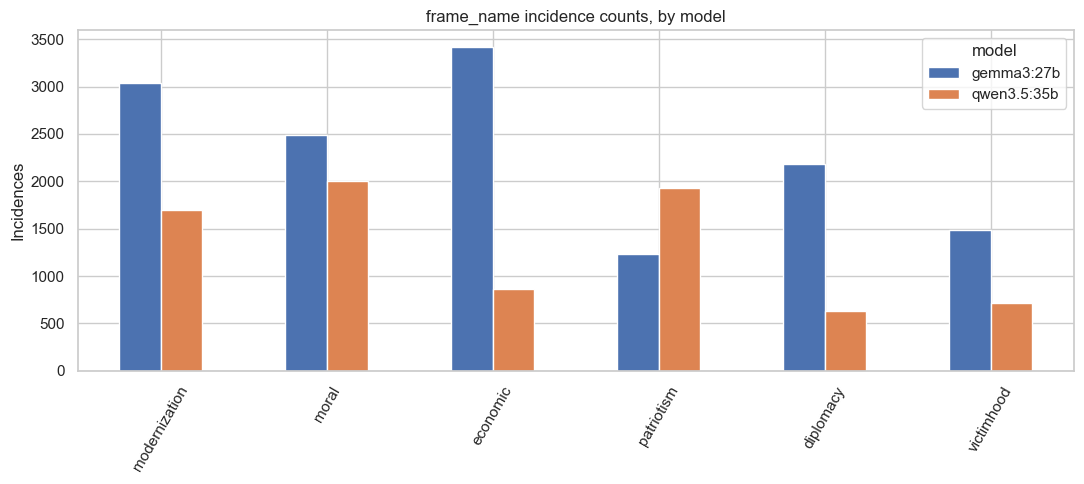

In [36]:

fig, ax = plt.subplots(figsize=(11, 5))
order = name_counts_agg.sort_values("count", ascending=False).index
name_counts.T.reindex(order).plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("frame_name incidence counts, by model")
ax.set_ylabel("Incidences")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=60)
ax.legend(title="model")
plt.tight_layout()
plt.show()


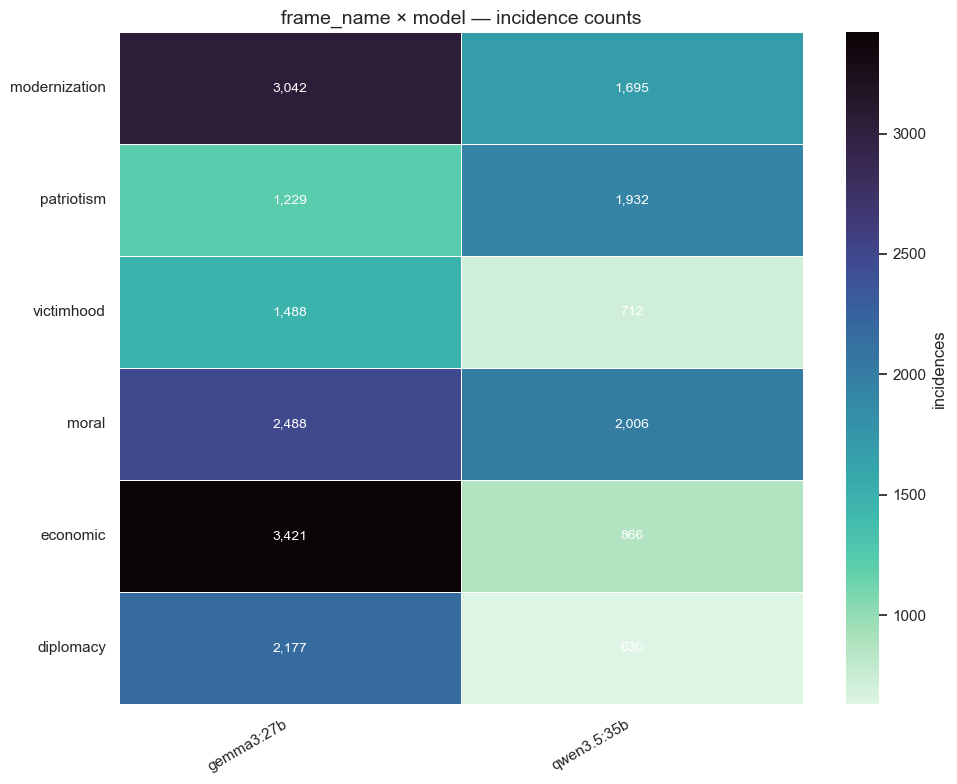

In [43]:
# Visualize as a matrix

plot_data = (
    name_counts
    .T
    .reindex(FRAME_NAMES)
    .reindex(columns=MODEL_ORDER)
    .fillna(0)
    .astype(int)
)

# Much wider figure
fig, ax = plt.subplots(
    figsize=(5 * len(plot_data.columns), 8)
)

# Draw heatmap WITHOUT seaborn annotations
sns.heatmap(
    plot_data,
    annot=False,
    cmap="mako_r",
    cbar_kws={"label": "incidences"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

# Manually add value to EVERY cell
for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        value = plot_data.iloc[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:,}",       # e.g. 3,192
            ha="center",
            va="center",
            fontsize=10,
            color="white",
        )

ax.set_title("frame_name × model — incidence counts", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("")

# X-axis model names
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

# Keep all y-axis labels visible
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

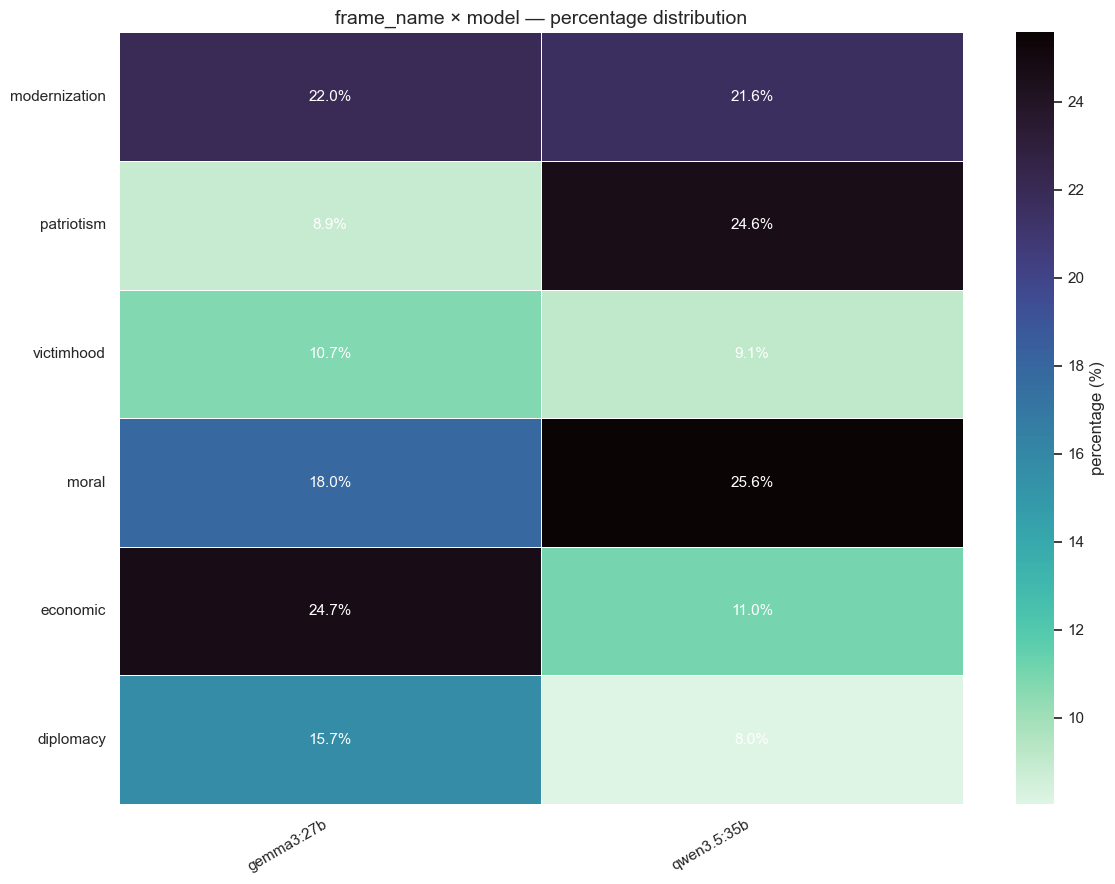

In [44]:
# Build the matrix with percentages instead of raw counts

plot_data = (
    name_counts
    .T
    .reindex(FRAME_NAMES)
    .reindex(columns=MODEL_ORDER)
    .fillna(0)
)

# Percentage within each model column
plot_pct = plot_data.div(plot_data.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(
    figsize=(6 * len(plot_pct.columns), 9)
)

# Draw heatmap without automatic annotations
sns.heatmap(
    plot_pct,
    annot=False,
    cmap="mako_r",
    cbar_kws={"label": "percentage (%)"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

# Manually write percentage in every cell
for i in range(plot_pct.shape[0]):
    for j in range(plot_pct.shape[1]):
        value = plot_pct.iloc[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=11,
            color="white",
            clip_on=False,
        )

ax.set_title("frame_name × model — percentage distribution", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

## Frame polarity

For each of the 6 substantive frames, how often is it invoked positively vs. negatively, and does that balance
differ by model?


In [45]:

pol_counts = (
    exploded.groupby(["model", "frame_name", "polarity"], observed=True)
            .size()
            .unstack("polarity", fill_value=0)
            .reindex(columns=POLARITIES, fill_value=0)
)
pol_counts["net_positive"] = pol_counts["positive"] - pol_counts["negative"]
pol_counts["positive_share"] = pol_counts["positive"] / (pol_counts["positive"] + pol_counts["negative"]).replace(0, np.nan)

print("Positive / negative incidence counts by model and frame:")
display(pol_counts.round(3))


Positive / negative incidence counts by model and frame:


polarity                   positive  negative  net_positive  positive_share
model       frame_name                                                     
gemma3:27b  modernization      1132      1910          -778           0.372
            patriotism         1130        99          1031           0.919
            victimhood         1476        12          1464           0.992
            moral               327      2161         -1834           0.131
            economic            229      3192         -2963           0.067
            diplomacy           940      1237          -297           0.432
qwen3.5:35b modernization       826       869           -43           0.487
            patriotism         1476       456          1020           0.764
            victimhood          711         1           710           0.999
            moral                80      1926         -1846           0.040
            economic             20       846          -826           0.023
            diplomacy           261       369          -108           0.414

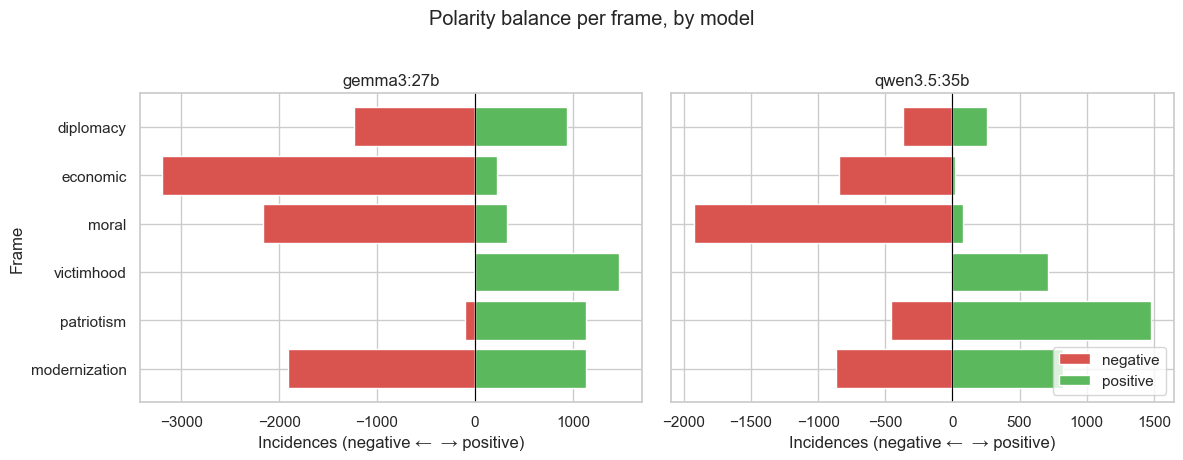

In [26]:

# Diverging bar chart: negative bars to the left, positive bars to the right, one panel per model.
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(6 * len(MODEL_ORDER), 4.5), sharey=True, squeeze=False)
axes = axes[0]

for ax, model in zip(axes, MODEL_ORDER):
    sub = pol_counts.loc[model].reindex(FRAME_NAMES) if model in pol_counts.index.get_level_values(0) else \
          pd.DataFrame(0, index=FRAME_NAMES, columns=["negative", "positive"])
    ax.barh(sub.index.astype(str), -sub["negative"], color="#d9534f", label="negative")
    ax.barh(sub.index.astype(str), sub["positive"], color="#5cb85c", label="positive")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(str(model))
    ax.set_xlabel("Incidences (negative \u2190  \u2192 positive)")

axes[0].set_ylabel("Frame")
axes[-1].legend(loc="lower right")
fig.suptitle("Polarity balance per frame, by model", y=1.02)
plt.tight_layout()
plt.show()


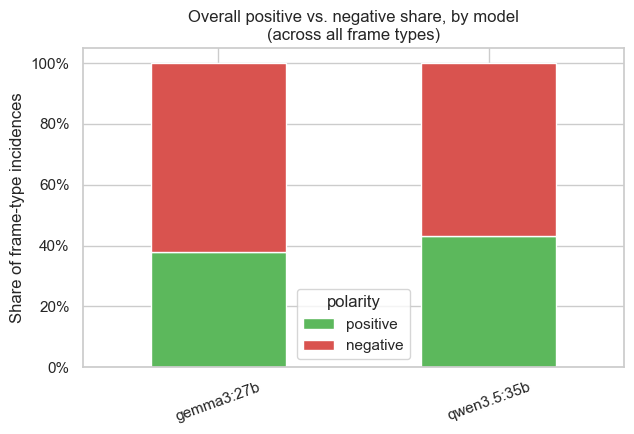

polarity,positive,negative
model,,
gemma3:27b,37.8,62.2
qwen3.5:35b,43.0,57.0


In [46]:

# Overall positive vs negative totals across all frames, by model — a compact summary view.
overall_pol = (
    exploded.groupby(["model", "polarity"], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(columns=POLARITIES, fill_value=0)
            .reindex(MODEL_ORDER)
)
overall_pol_share = overall_pol.div(overall_pol.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
overall_pol_share.plot(kind="bar", stacked=True, ax=ax, color=["#5cb85c", "#d9534f"], edgecolor="white")
ax.set_title("Overall positive vs. negative share, by model\n(across all frame types)")
ax.set_ylabel("Share of frame-type incidences")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="polarity")
plt.tight_layout()
plt.show()

overall_pol_share.round(3) * 100


In [35]:

# --- Aggregate: across all models combined ----------------------------------
polarity_agg = (
    exploded.groupby("polarity", observed=True)
            .size()
            .reindex(POLARITIES, fill_value=0)
            .rename("count")
            .to_frame()
)
polarity_agg["share"] = polarity_agg["count"] / polarity_agg["count"].sum() * 100

print("polarity counts aggregated across all models:")
display(polarity_agg.sort_values("count", ascending=False).round({"share": 3}))


polarity counts aggregated across all models:


,count,share
polarity,,
negative,13078,60.306
positive,8608,39.694


## Association between frame and polarity 

In [68]:
from scipy.stats import chi2_contingency


# ============================================================
# FRAME × POLARITY ASSOCIATION
# ============================================================

POLARITY_ORDER = ["positive", "negative"]


def cramers_v(table):
    """Bias-corrected Cramér's V."""
    
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = table.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(kcorr - 1, rcorr - 1)

    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

In [69]:
# Overall association between frame_name and polarity, across all models combined.

# Raw contingency table
frame_pol = (
    pd.crosstab(
        dated["frame_name"],
        dated["polarity"]
    )
    .reindex(
        index=FRAME_NAMES,
        columns=POLARITY_ORDER,
        fill_value=0
    )
)

# P(polarity | frame)
frame_pol_pct = (
    frame_pol
    .div(frame_pol.sum(axis=1), axis=0)
    .fillna(0)
    * 100
)

# Statistical association
chi2, p, dof, expected = chi2_contingency(frame_pol)

print(f"Chi-square = {chi2:.2f}")
print(f"df = {dof}")
print(f"p = {p:.4g}")
print(f"Cramér's V = {cramers_v(frame_pol):.3f}")

Chi-square = 9525.44
df = 5
p = 0
Cramér's V = 0.663


The chi-square test of independence revealed a significant association between frame type and polarity, χ²(5) = 9525.44, p < .001. The association is strong, Cramér’s V = .663, indicating substantial differences in the distribution of positive and negative polarity across frames. Cramér's V is particularly useful here because unlike the p-value it tells you the strength of association between frame and polarity, and you can compare that across models. The heatmaps below provide additional information on which frames drive this relationship. 

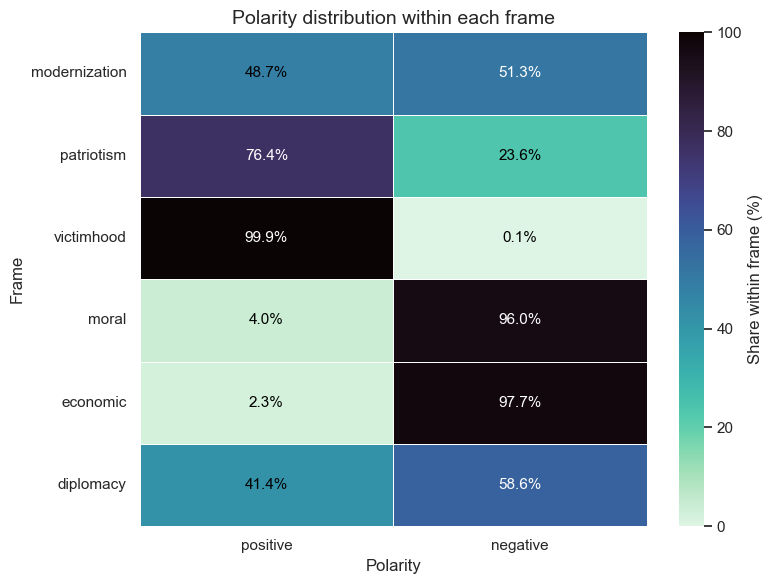

In [146]:
fig, ax = plt.subplots(figsize=(8, 6))

# Heatmap without Seaborn annotations
sns.heatmap(
    frame_pol_pct,
    cmap="mako_r",
    annot=False,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Share within frame (%)"},
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

# ------------------------------------------------------------
# Manually annotate EVERY cell
# ------------------------------------------------------------

n_rows, n_cols = frame_pol_pct.shape

for i in range(n_rows):
    for j in range(n_cols):

        value = frame_pol_pct.iat[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=11,

            # Adapt text color to background
            color="white" if value > 50 else "black",

            # Make sure text stays above heatmap
            zorder=10,
            clip_on=False
        )

# Explicitly preserve the full matrix
ax.set_xlim(0, n_cols)
ax.set_ylim(n_rows, 0)

ax.set_title(
    "Polarity distribution within each frame",
    fontsize=14
)

ax.set_xlabel("Polarity")
ax.set_ylabel("Frame")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

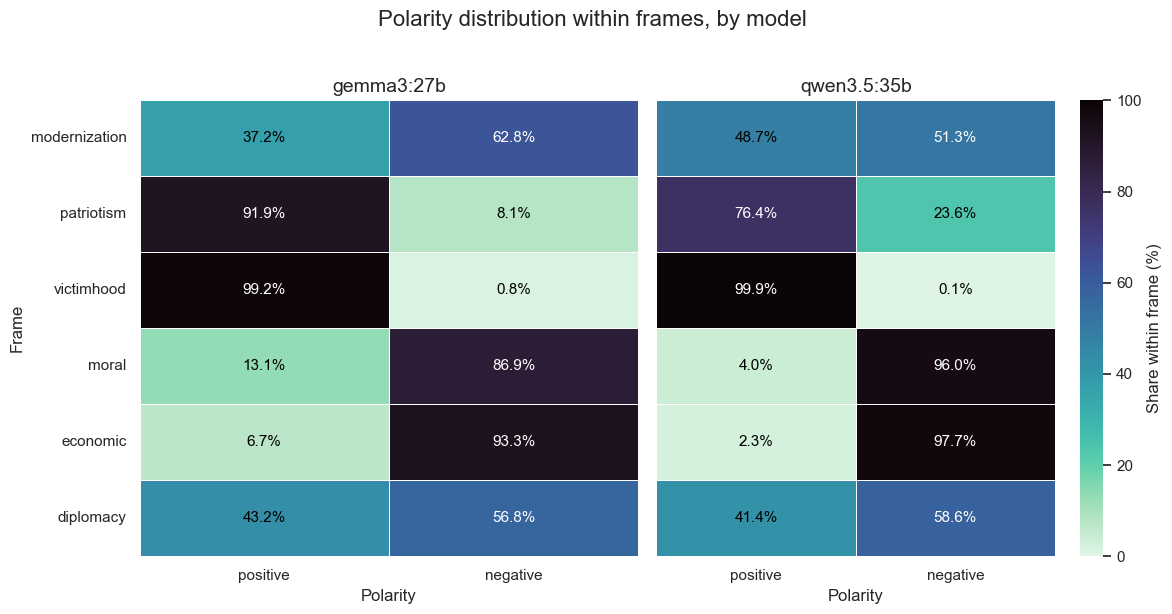

Finally, Pearson residuals are calculated to show exactly which combinations occur more or less often than expected under independence. Positive residuals mean “more cases than expected,” negative residuals mean “fewer than expected.” As a rule of thumb, values beyond about ±1.96 are notable, and your values are far beyond that in most cells. 

In [147]:

# ============================================================
# STANDARDIZED PEARSON RESIDUALS
# FRAME NAME × POLARITY
# ============================================================

POLARITY_ORDER = ["positive", "negative"]


def standardized_residuals(table):
    """
    Calculate adjusted standardized Pearson residuals.

    Rough interpretation:
        |residual| < 1.96  -> not significantly different
        residual > 1.96    -> more frequent than expected
        residual < -1.96   -> less frequent than expected
    """

    observed = table.to_numpy()

    # Expected frequencies under independence
    chi2, p, dof, expected = chi2_contingency(observed)

    n = observed.sum()

    # Marginal proportions
    row_prop = observed.sum(axis=1) / n
    col_prop = observed.sum(axis=0) / n

    # Adjusted standardized residual
    denominator = np.sqrt(
        expected
        * (1 - row_prop[:, None])
        * (1 - col_prop[None, :])
    )

    residuals = (
        (observed - expected)
        / denominator
    )

    return pd.DataFrame(
        residuals,
        index=table.index,
        columns=table.columns
    )

In [148]:
# ============================================================
# OVERALL FRAME × POLARITY TABLE
# ============================================================

frame_pol = (
    pd.crosstab(
        dated["frame_name"],
        dated["polarity"]
    )
    .reindex(
        index=FRAME_NAMES,
        columns=POLARITY_ORDER,
        fill_value=0
    )
)

residuals = standardized_residuals(frame_pol)

print(residuals.round(2))

polarity       positive  negative
frame_name                       
modernization      2.61     -2.61
patriotism        53.15    -53.15
victimhood        60.39    -60.39
moral            -47.15     47.15
economic         -50.63     50.63
diplomacy          3.59     -3.59


The overall pattern is very clear: patriotism and victimhood are disproportionately positive, while moral and economic frames are disproportionately negative; modernization and diplomacy lean positive but much more weakly.

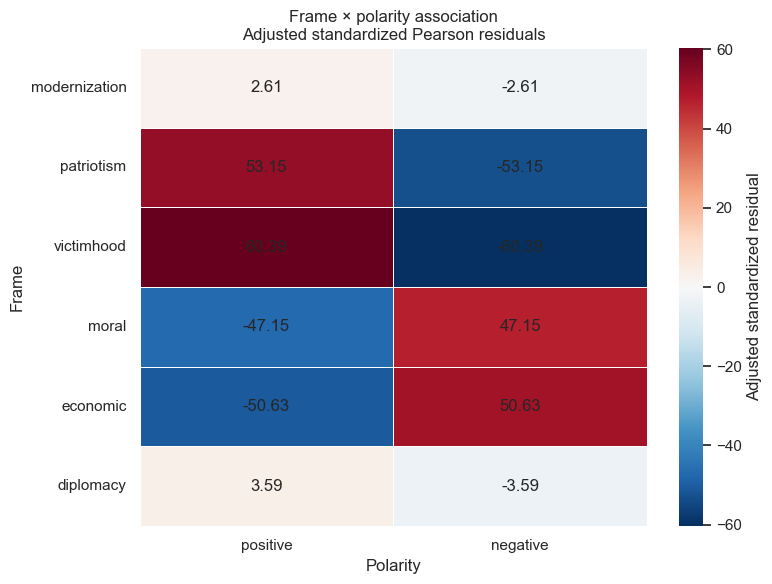

In [149]:
# ============================================================
# HEATMAP OF STANDARDIZED RESIDUALS
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)

max_abs = np.abs(
    residuals.to_numpy()
).max()

sns.heatmap(
    residuals,
    cmap="RdBu_r",
    center=0,
    vmin=-max_abs,
    vmax=max_abs,
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Adjusted standardized residual"
    },
    ax=ax
)

# --------------------------------------------------------
# MANUALLY ANNOTATE EVERY CELL
# --------------------------------------------------------
    
for i in range(n_rows):
    for j in range(n_cols):
        value = residuals.iat[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            zorder=10,
            clip_on=False
        )


ax.set_title(
    "Frame × polarity association\n"
    "Adjusted standardized Pearson residuals"
)

ax.set_xlabel("Polarity")
ax.set_ylabel("Frame")

plt.tight_layout()
plt.show()

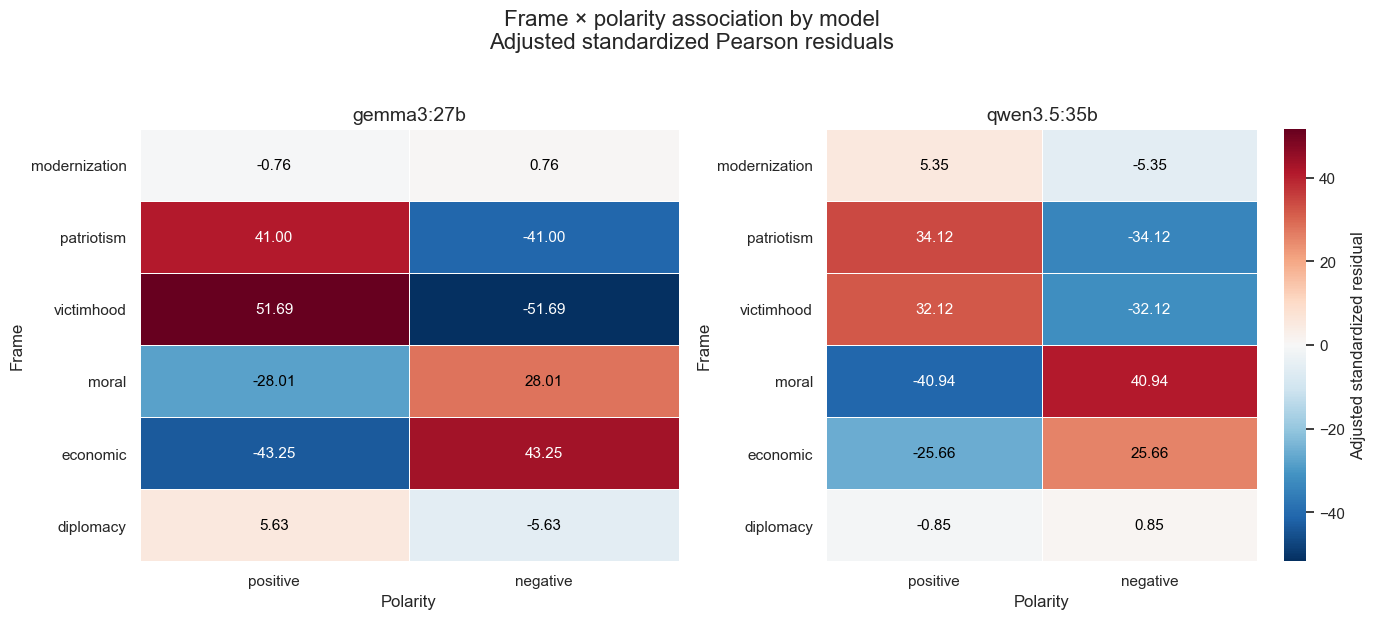

In [150]:
# ============================================================
# STANDARDIZED RESIDUALS BY MODEL
# SIDE-BY-SIDE + MANUAL ANNOTATIONS + FRAME LABELS
# ============================================================

residuals_by_model = {}

# ------------------------------------------------------------
# 1. Compute residuals for each model
# ------------------------------------------------------------

for model in MODEL_ORDER:

    sub = dated[
        dated["model"] == model
    ]

    table = (
        pd.crosstab(
            sub["frame_name"],
            sub["polarity"]
        )
        .reindex(
            index=FRAME_NAMES,
            columns=POLARITY_ORDER,
            fill_value=0
        )
    )

    # Remove frames absent from this model
    test_table = table.loc[
        table.sum(axis=1) > 0
    ]

    if test_table.empty:
        continue

    res = standardized_residuals(
        test_table
    )

    residuals_by_model[model] = res


# ------------------------------------------------------------
# 2. Models to plot
# ------------------------------------------------------------

models_to_plot = [
    model
    for model in MODEL_ORDER
    if model in residuals_by_model
]


# ------------------------------------------------------------
# 3. Common color scale
# ------------------------------------------------------------

global_max_abs = max(
    np.abs(res.to_numpy()).max()
    for res in residuals_by_model.values()
)


# ------------------------------------------------------------
# 4. Side-by-side heatmaps
# ------------------------------------------------------------

n_models = len(models_to_plot)

fig, axes = plt.subplots(
    1,
    n_models,
    figsize=(7 * n_models, 6),

    # IMPORTANT:
    # don't share y axis
    sharey=False,

    squeeze=False
)

axes = axes[0]


for idx, (ax, model) in enumerate(
    zip(axes, models_to_plot)
):

    res = residuals_by_model[model]

    n_rows, n_cols = res.shape

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    sns.heatmap(
        res,
        ax=ax,
        cmap="RdBu_r",
        center=0,

        # Same scale across models
        vmin=-global_max_abs,
        vmax=global_max_abs,

        # We add values ourselves
        annot=False,

        linewidths=0.5,
        linecolor="white",

        # Explicitly disable Seaborn labels;
        # we'll add them manually below
        yticklabels=False,
        xticklabels=False,

        # Colorbar only on final plot
        cbar=(idx == n_models - 1),

        cbar_kws={
            "label":
            "Adjusted standardized residual"
        } if idx == n_models - 1 else None
    )

    # --------------------------------------------------------
    # MANUALLY ANNOTATE EVERY CELL
    # --------------------------------------------------------

    for i in range(n_rows):
        for j in range(n_cols):

            value = res.iat[i, j]

            text_color = (
                "white"
                if abs(value) >
                global_max_abs * 0.55
                else "black"
            )

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=11,
                color=text_color,
                zorder=10,
                clip_on=False
            )

    # --------------------------------------------------------
    # MANUALLY SET FRAME NAMES
    # --------------------------------------------------------

    ax.set_yticks(
        np.arange(n_rows) + 0.5
    )

    ax.set_yticklabels(
        res.index,
        rotation=0,
        fontsize=11
    )

    # --------------------------------------------------------
    # MANUALLY SET POLARITY NAMES
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(n_cols) + 0.5
    )

    ax.set_xticklabels(
        res.columns,
        rotation=0,
        fontsize=11
    )

    # --------------------------------------------------------
    # Preserve full heatmap
    # --------------------------------------------------------

    ax.set_xlim(
        0,
        n_cols
    )

    ax.set_ylim(
        n_rows,
        0
    )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    ax.set_title(
        f"{model}",
        fontsize=14
    )

    ax.set_xlabel(
        "Polarity",
        fontsize=12
    )

    ax.set_ylabel(
        "Frame",
        fontsize=12
    )


# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------

fig.suptitle(
    "Frame × polarity association by model\n"
    "Adjusted standardized Pearson residuals",
    fontsize=16,
    y=1.03
)

plt.tight_layout()
plt.show()

## Frame type over time, by model

This section needs a usable date column (see Section 2). If none was found, the cells below will say so and
skip cleanly rather than error.

We bin time into `TIME_BIN_YEARS`-year buckets (configurable) to keep the visuals readable on a
multi-decade newspaper corpus. Set `TIME_BIN_YEARS = 1` for yearly resolution if your date range is short.


In [47]:

TIME_BIN_YEARS = 5  # widen/narrow the time buckets here

has_time = ok["_year"].notna().any()

if not has_time:
    print("No usable date information was found — skipping the time-based analysis.")
else:
    dated = exploded.dropna(subset=["_year"]).copy()
    dated["_year"] = dated["_year"].astype(int)
    min_year, max_year = int(dated["_year"].min()), int(dated["_year"].max())
    bin_start = (min_year // TIME_BIN_YEARS) * TIME_BIN_YEARS
    dated["year_bin"] = (dated["_year"] // TIME_BIN_YEARS * TIME_BIN_YEARS).astype(int)
    print(f"Date range: {min_year}-{max_year}. Binning into {TIME_BIN_YEARS}-year buckets "
          f"({dated['year_bin'].nunique()} bucket(s)).")


Date range: 1873-1949. Binning into 5-year buckets (16 bucket(s)).


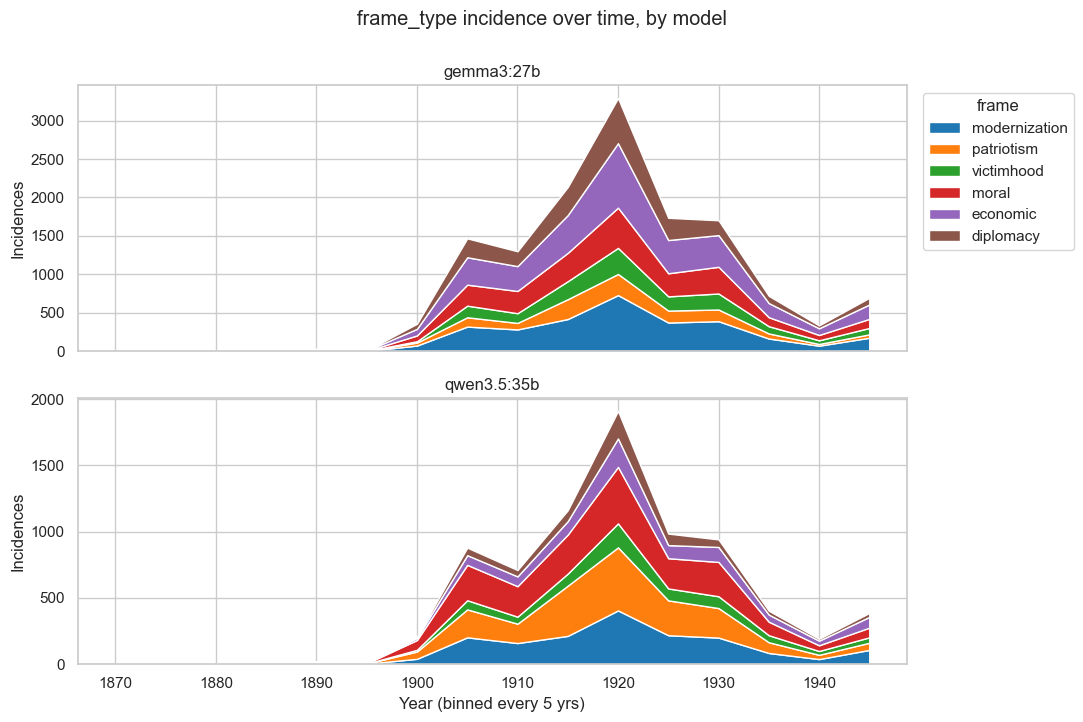

In [ ]:

# --- 6a. frame_type frequency over time, per model (small multiples of stacked area charts) ---
if has_time:
    n_models = len(MODEL_ORDER)
    fig, axes = plt.subplots(n_models, 1, figsize=(11, 3.6 * n_models), sharex=True, squeeze=False)
    axes = axes[:, 0]

    palette = sns.color_palette("tab10", n_colors=len(FRAME_NAMES))
    frame_colors = dict(zip(FRAME_NAMES, palette))

    for ax, model in zip(axes, MODEL_ORDER):
        sub = dated[dated["model"] == model]
        pivot = (
            sub.groupby(["year_bin", "frame_name"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_NAMES, fill_value=0)
               .sort_index()
        )
        if pivot.empty:
            ax.set_title(f"{model} (no dated rows)")
            continue
        ax.stackplot(
            pivot.index, [pivot[f] for f in FRAME_NAMES],
            labels=FRAME_NAMES, colors=[frame_colors[f] for f in FRAME_NAMES],
        )
        ax.set_title(str(model))
        ax.set_ylabel("Incidences")

    axes[-1].set_xlabel(f"Year (binned every {TIME_BIN_YEARS} yrs)")
    axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1), title="frame")
    fig.suptitle("frame_type incidence over time, by model", y=1.0)
    plt.tight_layout()
    plt.show()


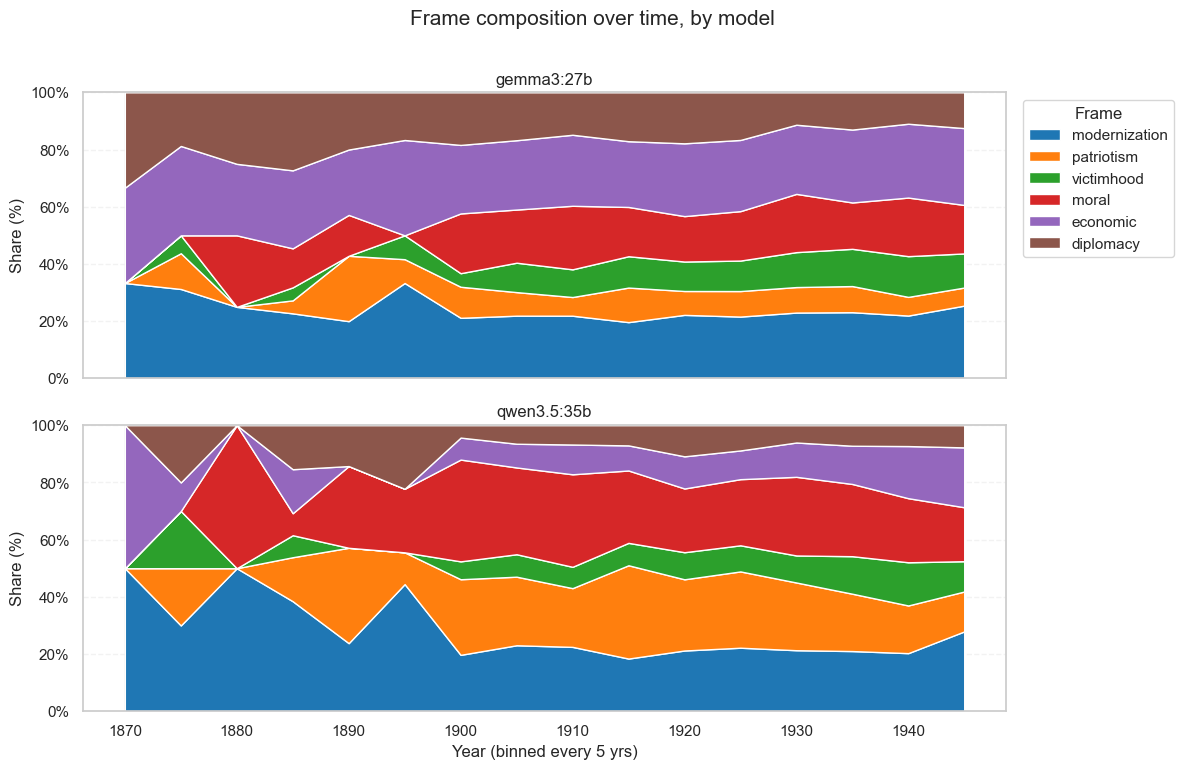

In [55]:
# --- 6b. Static 100% stacked frame composition over time, per model ---

import matplotlib


if has_time:
    n_models = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_models,
        1,
        figsize=(12, 3.8 * n_models),
        sharex=True,
        squeeze=False
    )
    axes = axes[:, 0]

    # Consistent colors across models
    palette = sns.color_palette("tab10", n_colors=len(FRAME_NAMES))
    frame_colors = dict(zip(FRAME_NAMES, palette))

    for ax, model in zip(axes, MODEL_ORDER):

        sub = dated[dated["model"] == model]

        # Raw incidence counts
        pivot = (
            sub.groupby(["year_bin", "frame_name"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_NAMES, fill_value=0)
               .sort_index()
        )

        if pivot.empty:
            ax.set_title(f"{model} (no dated rows)")
            continue

        # Convert each year to percentages
        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(row_totals.replace(0, np.nan), axis=0)
            .fillna(0)
            * 100
        )

        # 100% stacked area chart
        ax.stackplot(
            pivot_pct.index,
            *[pivot_pct[f] for f in FRAME_NAMES],
            labels=FRAME_NAMES,
            colors=[frame_colors[f] for f in FRAME_NAMES],
        )

        ax.set_title(str(model))
        ax.set_ylabel("Share (%)")

        # Always use 0–100% scale
        ax.set_ylim(0, 100)

        # Percentage labels on y-axis
        ax.yaxis.set_major_formatter(
            matplotlib.ticker.PercentFormatter(xmax=100)
        )

        # Light horizontal grid
        ax.grid(
            axis="y",
            alpha=0.25,
            linestyle="--"
        )

    # X-axis
    axes[-1].set_xlabel(
        f"Year (binned every {TIME_BIN_YEARS} yrs)"
    )

    # Single legend
    axes[0].legend(
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        title="Frame"
    )

    fig.suptitle(
        "Frame composition over time, by model",
        fontsize=15,
        y=1.01
    )

    plt.tight_layout()

    # Optional: save high-resolution static figure
    plt.savefig(
        "frame_composition_over_time.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [93]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# --- 6a. Interactive frame frequency over time, per model ---

if has_time:
    n_models = len(MODEL_ORDER)

    # One subplot per model
    fig = make_subplots(
        rows=n_models,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        subplot_titles=[str(model) for model in MODEL_ORDER],
    )

    # Consistent color for each frame across all models
    palette = px.colors.qualitative.Plotly
    frame_colors = {
        frame: palette[i % len(palette)]
        for i, frame in enumerate(FRAME_NAMES)
    }

    for row, model in enumerate(MODEL_ORDER, start=1):

        sub = dated[dated["model"] == model]

        pivot = (
            sub.groupby(["year_bin", "frame_name"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_NAMES, fill_value=0)
               .sort_index()
        )

        if pivot.empty:
            continue

        for i, frame in enumerate(FRAME_NAMES):

            fig.add_trace(
                go.Scatter(
                    x=pivot.index,
                    y=pivot[frame],
                    name=frame,

                    # Creates stacked area chart
                    stackgroup="one",

                    mode="lines",
                    line=dict(
                        width=0.5,
                        color=frame_colors[frame]
                    ),
                    fillcolor=frame_colors[frame],

                    # Only show each frame once in legend
                    showlegend=(row == 1),

                    # Better tooltip
                    hovertemplate=(
                        f"<b>{frame}</b><br>"
                        "Year: %{x}<br>"
                        "Incidences: %{y:,}"
                        "<extra></extra>"
                    ),
                ),
                row=row,
                col=1,
            )

    # Axis titles
    for row in range(1, n_models + 1):
        fig.update_yaxes(
            title_text="Incidences",
            row=row,
            col=1
        )

    fig.update_xaxes(
        title_text=f"Year (binned every {TIME_BIN_YEARS} yrs)",
        row=n_models,
        col=1
    )

    fig.update_layout(
        title={
            "text": "Frame incidence over time, by model",
            "x": 0.5
        },

        height=350 * n_models,
        width=1200,

        # hovermode="x unified",
        hovermode="closest",

        legend=dict(
            title="Frame",
            orientation="v",
            x=1.02,
            y=1
        ),

        margin=dict(
            l=70,
            r=220,
            t=100,
            b=70
        ),
    )

    fig.show()

In [52]:
# export the plot 

fig.write_html(
    "frame_incidence_over_time.html",
    include_plotlyjs=True
)



In [92]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# --- 6a. Interactive 100% stacked frame frequency over time, per model ---

if has_time:
    n_models = len(MODEL_ORDER)

    fig = make_subplots(
        rows=n_models,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        subplot_titles=[str(model) for model in MODEL_ORDER],
    )

    # Consistent colors across models
    palette = px.colors.qualitative.Plotly
    frame_colors = {
        frame: palette[i % len(palette)]
        for i, frame in enumerate(FRAME_NAMES)
    }

    for row, model in enumerate(MODEL_ORDER, start=1):

        sub = dated[dated["model"] == model]

        # Raw incidence counts
        pivot = (
            sub.groupby(["year_bin", "frame_name"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_NAMES, fill_value=0)
               .sort_index()
        )

        if pivot.empty:
            continue

        # -----------------------------------
        # Convert each year to percentages
        # -----------------------------------
        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(row_totals.replace(0, float("nan")), axis=0)
            .fillna(0)
            * 100
        )

        # Add one stacked area per frame
        for frame in FRAME_NAMES:

            fig.add_trace(
                go.Scatter(
                    x=pivot_pct.index,
                    y=pivot_pct[frame],

                    name=frame,
                    stackgroup="one",

                    mode="lines",

                    line=dict(
                        width=0.5,
                        color=frame_colors[frame]
                    ),

                    fillcolor=frame_colors[frame],

                    # Show legend only once
                    showlegend=(row == 1),

                    # Interactive tooltip
                    hovertemplate=(
                        f"<b>{frame}</b><br>"
                        "Year: %{x}<br>"
                        "Share: %{y:.1f}%"
                        "<extra></extra>"
                    ),
                ),
                row=row,
                col=1,
            )

        # Force percentage scale
        fig.update_yaxes(
            title_text="Share (%)",
            range=[0, 100],
            ticksuffix="%",
            row=row,
            col=1,
        )

    # X-axis title on bottom subplot
    fig.update_xaxes(
        title_text=f"Year (binned every {TIME_BIN_YEARS} yrs)",
        row=n_models,
        col=1,
    )

    fig.update_layout(
        title={
            "text": "Frame composition over time, by model",
            "x": 0.5,
        },

        height=350 * n_models,
        width=1200,

        # hovermode="x unified",
        hovermode="closest",

        legend=dict(
            title="Frame",
            orientation="v",
            x=1.02,
            y=1,
        ),

        margin=dict(
            l=70,
            r=220,
            t=100,
            b=70,
        ),
    )

    # Display interactively
    fig.show()

    # Export as standalone interactive HTML
    fig.write_html(
        "frame_composition_over_time.html",
        include_plotlyjs=True
    )

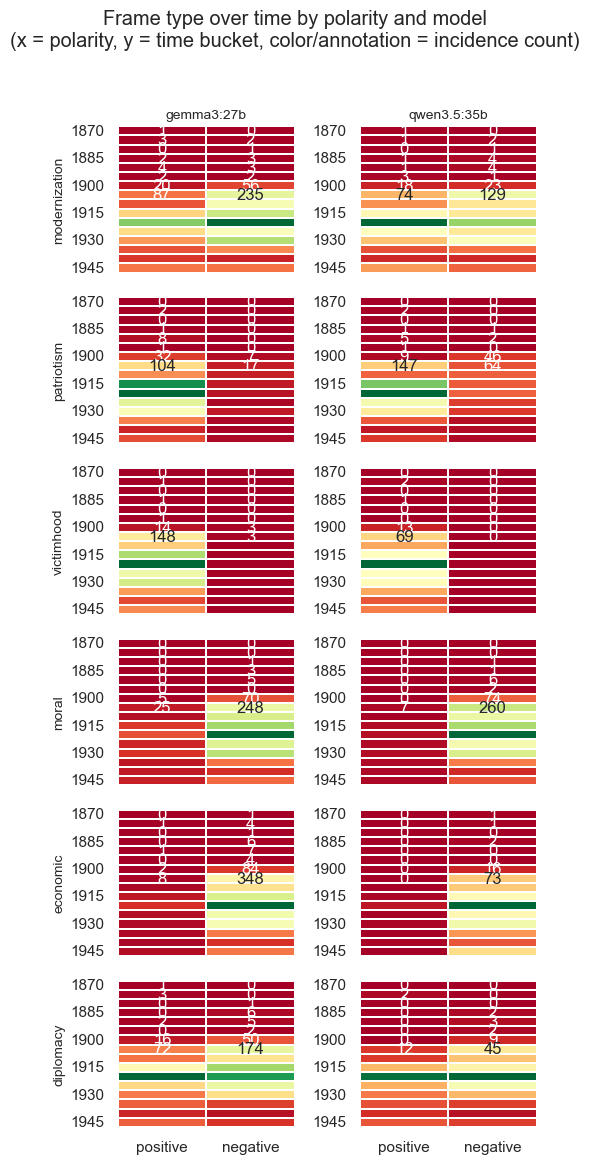

In [49]:

# --- 6b. Polarity x time heatmaps, faceted by frame and by model ------------
# Layout: rows = frame, columns = model. Within each small heatmap:
#   x-axis = polarity (negative, positive), y-axis = time bucket.
if has_time:
    n_frames = len(FRAME_NAMES)
    n_models = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_frames, n_models,
        figsize=(2.6 * n_models, 1.9 * n_frames),
        sharex=True, squeeze=False,
    )

    year_bins = sorted(dated["year_bin"].unique())

    for i, frame in enumerate(FRAME_NAMES):
        for j, model in enumerate(MODEL_ORDER):
            ax = axes[i, j]
            sub = dated[(dated["frame_name"] == frame) & (dated["model"] == model)]
            pivot = (
                sub.groupby(["year_bin", "polarity"], observed=True)
                   .size()
                   .unstack(fill_value=0)
                   .reindex(index=year_bins, columns=POLARITIES, fill_value=0)
            )
            sns.heatmap(
                pivot, ax=ax, cmap="RdYlGn", cbar=False, annot=(n_frames * n_models <= 24),
                fmt="d", linewidths=0.3, linecolor="white",
            )
            if i == 0:
                ax.set_title(str(model), fontsize=10)
            if j == 0:
                ax.set_ylabel(frame, fontsize=10)
            else:
                ax.set_ylabel("")
            ax.set_xlabel("")

    fig.suptitle(
        "Frame type over time by polarity and model\n(x = polarity, y = time bucket, color/annotation = incidence count)",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()
else:
    print("Skipping polarity x time heatmaps (no usable date information).")


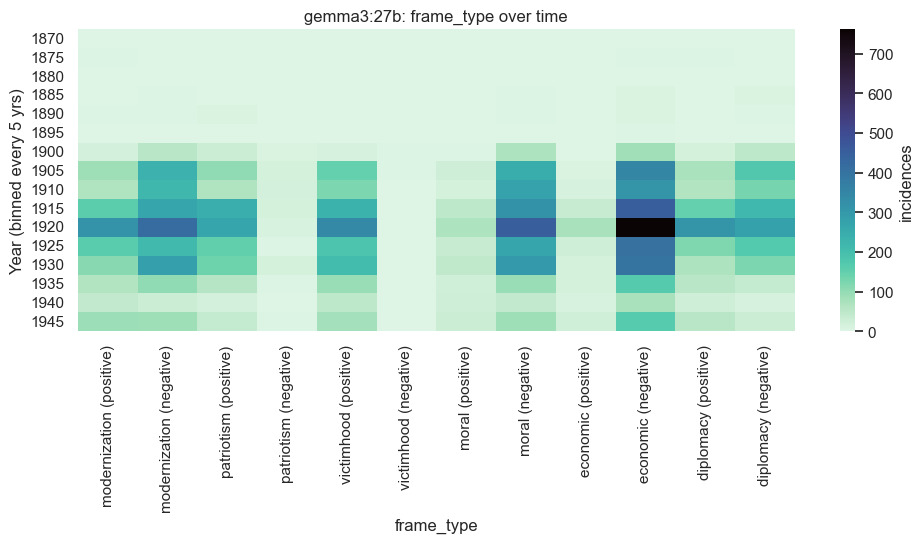

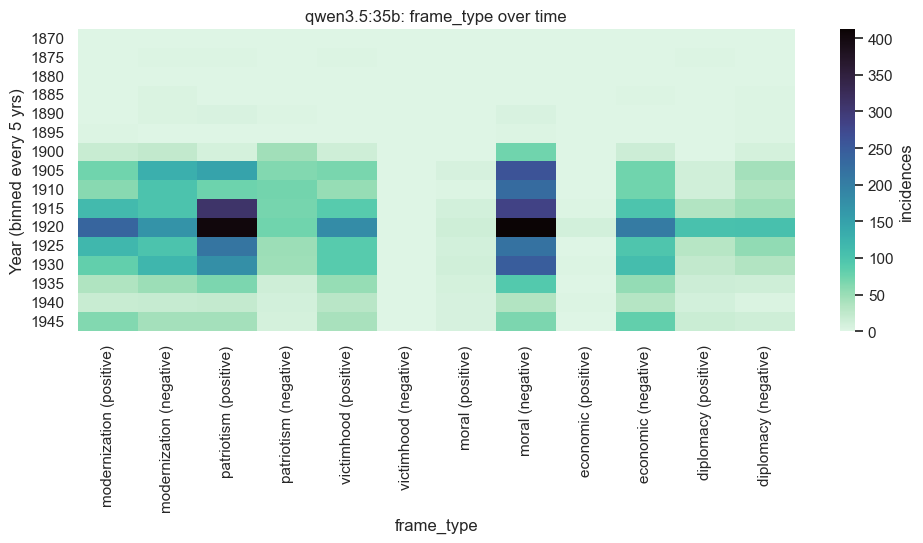

In [50]:

# --- 6c. A single combined heatmap alternative: time (rows) x polarity-within-frame (columns) ---
# Useful when you want one figure per model instead of a big grid.
if has_time:
    for model in MODEL_ORDER:
        sub = dated[dated["model"] == model]
        pivot = (
            sub.assign(frame_polarity=sub["frame_name"].astype(str) + " (" + sub["polarity"].astype(str) + ")")
               .groupby(["year_bin", "frame_polarity"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_TYPE_ORDER, fill_value=0)
               .reindex(year_bins, fill_value=0)
        )
        if pivot.to_numpy().sum() == 0:
            continue
        fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(pivot))))
        sns.heatmap(pivot, ax=ax, cmap="mako_r", annot=False, cbar_kws={"label": "incidences"})
        ax.set_title(f"{model}: frame_type over time")
        ax.set_xlabel("frame_type")
        ax.set_ylabel(f"Year (binned every {TIME_BIN_YEARS} yrs)")
        plt.tight_layout()
        plt.show()


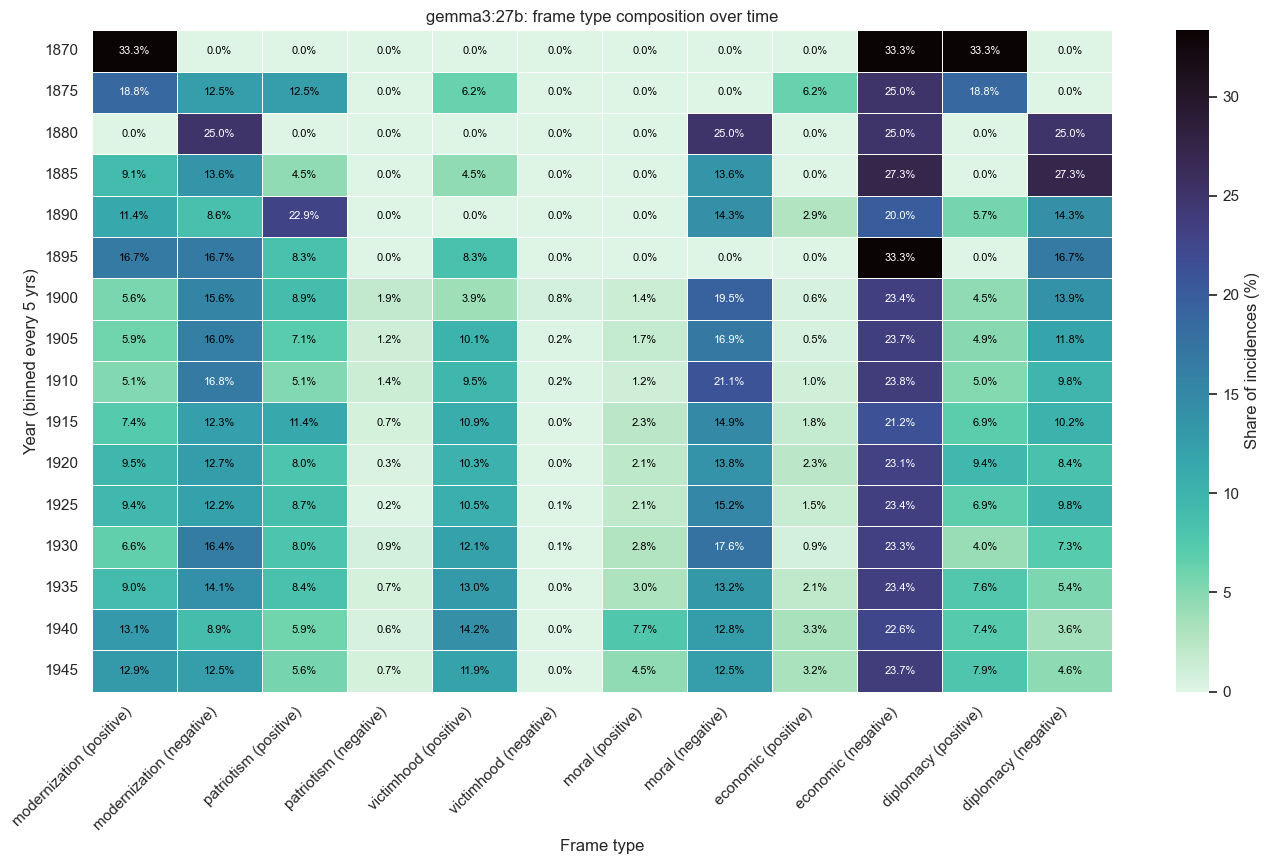

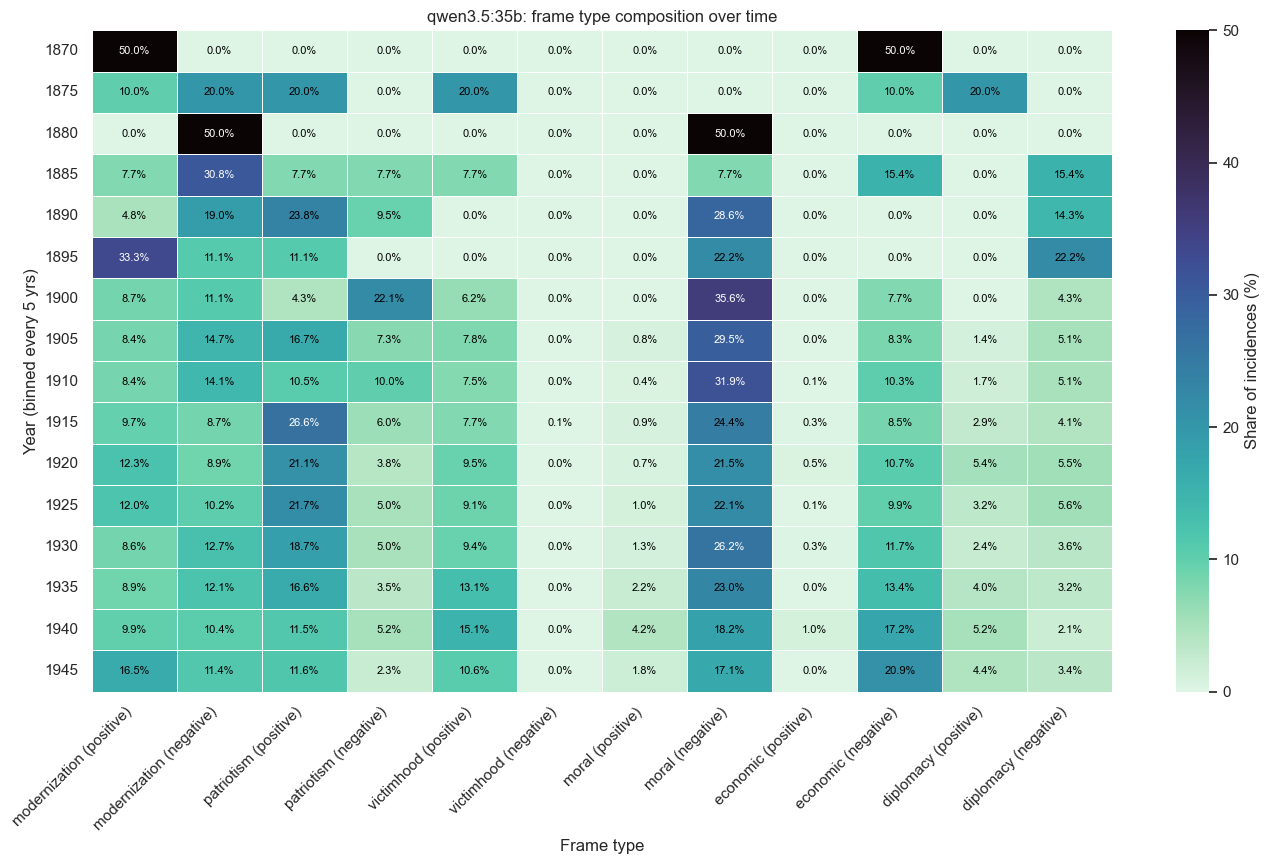

In [57]:
if has_time:
    for model in MODEL_ORDER:
        sub = dated[dated["model"] == model]

        pivot = (
            sub.assign(
                frame_polarity=(
                    sub["frame_name"].astype(str)
                    + " ("
                    + sub["polarity"].astype(str)
                    + ")"
                )
            )
            .groupby(["year_bin", "frame_polarity"], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(columns=FRAME_TYPE_ORDER, fill_value=0)
            .reindex(year_bins, fill_value=0)
        )

        if pivot.to_numpy().sum() == 0:
            continue

        # Convert each year row to percentages
        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(row_totals.replace(0, np.nan), axis=0)
            .fillna(0)
            * 100
        )

        # Make the figure large enough for every row and column
        n_rows, n_cols = pivot_pct.shape

        fig, ax = plt.subplots(
            figsize=(
                max(14, 1.15 * n_cols),
                max(6, 0.55 * n_rows)
            )
        )

        # Heatmap only
        sns.heatmap(
            pivot_pct,
            ax=ax,
            cmap="mako_r",
            annot=False,
            vmin=0,
            vmax=pivot_pct.to_numpy().max(),
            cbar_kws={"label": "Share of incidences (%)"},
            linewidths=0.4,
            linecolor="white",
        )

        # -------------------------------------------------
        # Manually annotate EVERY cell
        # -------------------------------------------------
        vmax = pivot_pct.to_numpy().max()

        for row_idx in range(n_rows):
            for col_idx in range(n_cols):
                value = pivot_pct.iat[row_idx, col_idx]

                # Choose text color based on cell intensity
                text_color = (
                    "white"
                    if value > vmax * 0.5
                    else "black"
                )

                ax.text(
                    col_idx + 0.5,
                    row_idx + 0.5,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=text_color,
                    clip_on=False,
                    zorder=10,
                )

        # Explicitly preserve full heatmap extent
        ax.set_xlim(0, n_cols)
        ax.set_ylim(n_rows, 0)

        ax.set_title(
            f"{model}: frame type composition over time"
        )

        ax.set_xlabel("Frame type")
        ax.set_ylabel(
            f"Year (binned every {TIME_BIN_YEARS} yrs)"
        )

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=45,
            ha="right"
        )

        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0
        )

        plt.tight_layout()
        plt.show()

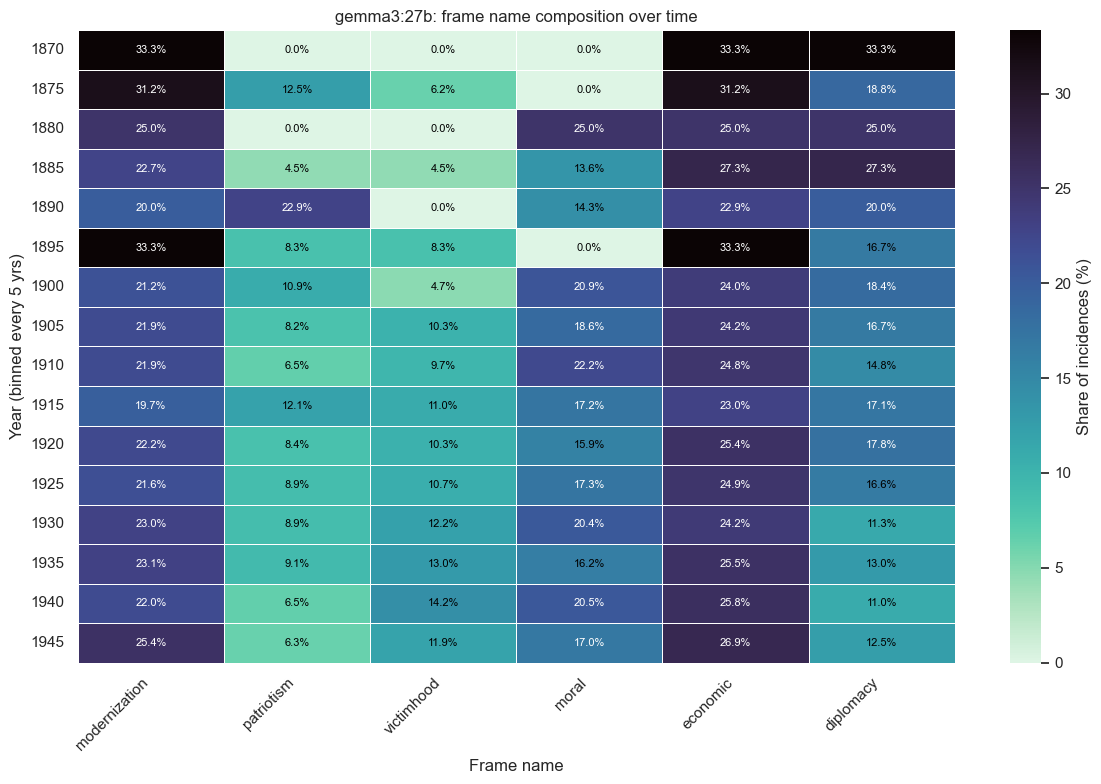

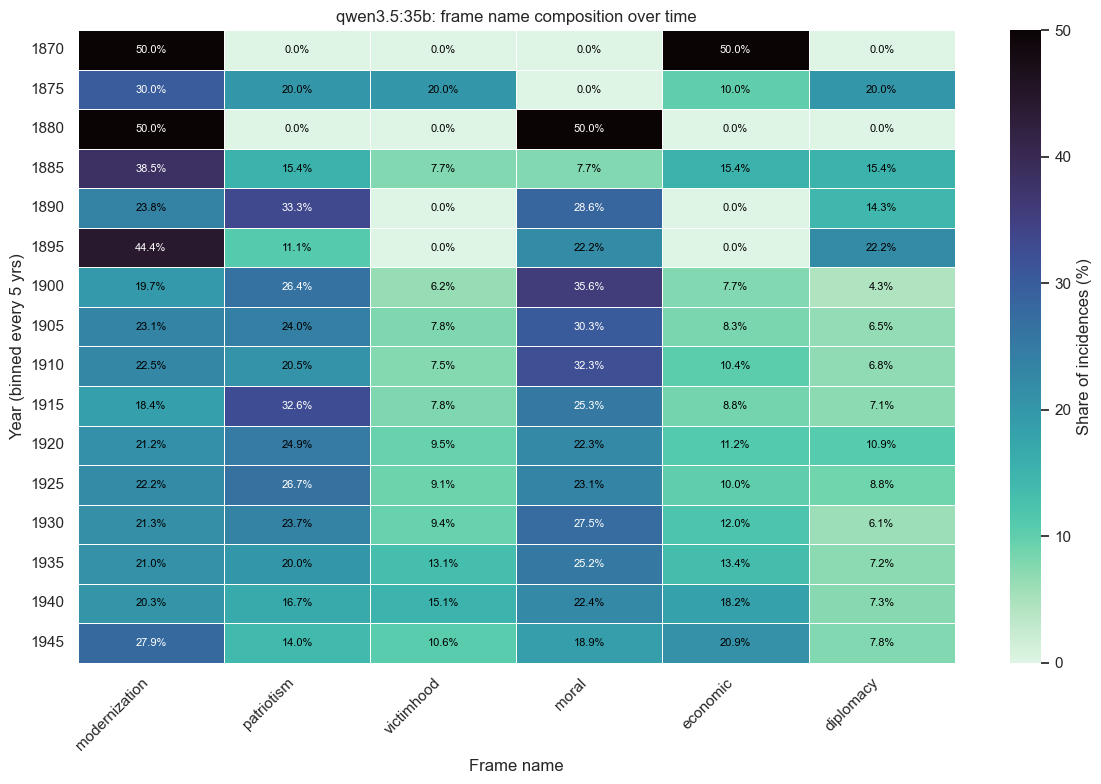

In [61]:
# --- 6c. Heatmap: time (rows) x frame_name (columns), shown as shares ---

if has_time:
    for model in MODEL_ORDER:
        sub = dated[dated["model"] == model]

        # Raw counts by year bin and frame name
        pivot = (
            sub.groupby(["year_bin", "frame_name"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_NAMES, fill_value=0)
               .reindex(year_bins, fill_value=0)
        )

        if pivot.to_numpy().sum() == 0:
            continue

        # Convert each year row to percentages
        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(row_totals.replace(0, np.nan), axis=0)
            .fillna(0)
            * 100
        )

        n_rows, n_cols = pivot_pct.shape

        fig, ax = plt.subplots(
            figsize=(
                max(12, 1.4 * n_cols),
                max(5, 0.5 * n_rows)
            )
        )

        sns.heatmap(
            pivot_pct,
            ax=ax,
            cmap="mako_r",
            annot=False,
            vmin=0,
            cbar_kws={"label": "Share of incidences (%)"},
            linewidths=0.4,
            linecolor="white",
        )

        # Manually annotate every cell
        vmax = pivot_pct.to_numpy().max()

        for i in range(n_rows):
            for j in range(n_cols):
                value = pivot_pct.iat[i, j]

                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white" if value > vmax * 0.5 else "black",
                    zorder=10,
                )

        ax.set_title(f"{model}: frame name composition over time")
        ax.set_xlabel("Frame name")
        ax.set_ylabel(
            f"Year (binned every {TIME_BIN_YEARS} yrs)"
        )

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=45,
            ha="right"
        )

        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0
        )

        plt.tight_layout()
        plt.show()

## Polarity over time

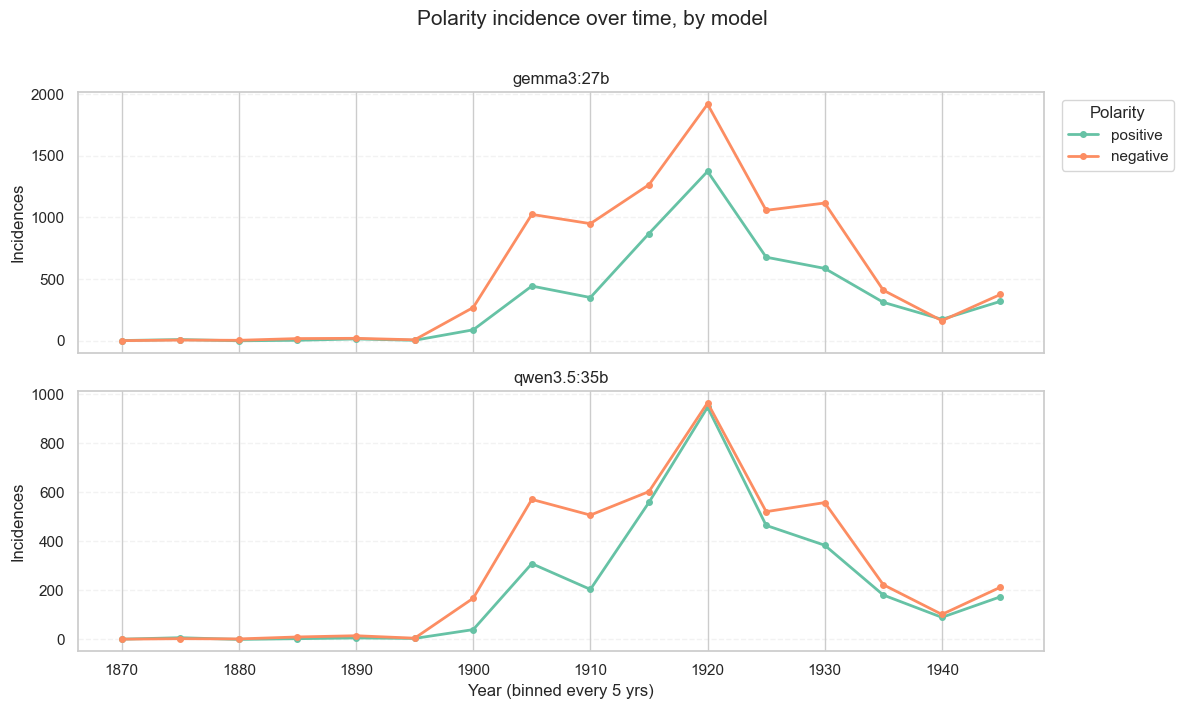

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


# ============================================================
# SETTINGS
# ============================================================

# Adjust if you want a specific order
POLARITY_ORDER = [
    "positive",
    "negative",
]

# Keep only polarities actually present in the data
POLARITY_ORDER = [
    p for p in POLARITY_ORDER
    if p in dated["polarity"].astype(str).unique()
]

# Add any unexpected polarity labels that weren't explicitly listed
for p in dated["polarity"].astype(str).unique():
    if p not in POLARITY_ORDER:
        POLARITY_ORDER.append(p)

# Consistent colors across every visualization
palette = sns.color_palette(
    "Set2",
    n_colors=len(POLARITY_ORDER)
)
polarity_colors = dict(zip(POLARITY_ORDER, palette))


# ============================================================
# 1. TIMELINE — RAW POLARITY COUNTS OVER TIME
#    One panel per model
# ============================================================

if has_time:

    n_models = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_models,
        1,
        figsize=(12, 3.5 * n_models),
        sharex=True,
        squeeze=False,
    )

    axes = axes[:, 0]

    for ax, model in zip(axes, MODEL_ORDER):

        sub = dated[dated["model"] == model]

        pivot = (
            sub.groupby(
                ["year_bin", "polarity"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                columns=POLARITY_ORDER,
                fill_value=0
            )
            .reindex(
                year_bins,
                fill_value=0
            )
        )

        if pivot.to_numpy().sum() == 0:
            ax.set_title(f"{model} — no dated rows")
            continue

        # One line per polarity
        for polarity in POLARITY_ORDER:
            ax.plot(
                pivot.index,
                pivot[polarity],
                marker="o",
                linewidth=2,
                markersize=4,
                label=polarity,
                color=polarity_colors[polarity],
            )

        ax.set_title(str(model))
        ax.set_ylabel("Incidences")

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.25,
        )

    axes[-1].set_xlabel(
        f"Year (binned every {TIME_BIN_YEARS} yrs)"
    )

    axes[0].legend(
        title="Polarity",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
    )

    fig.suptitle(
        "Polarity incidence over time, by model",
        fontsize=15,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()

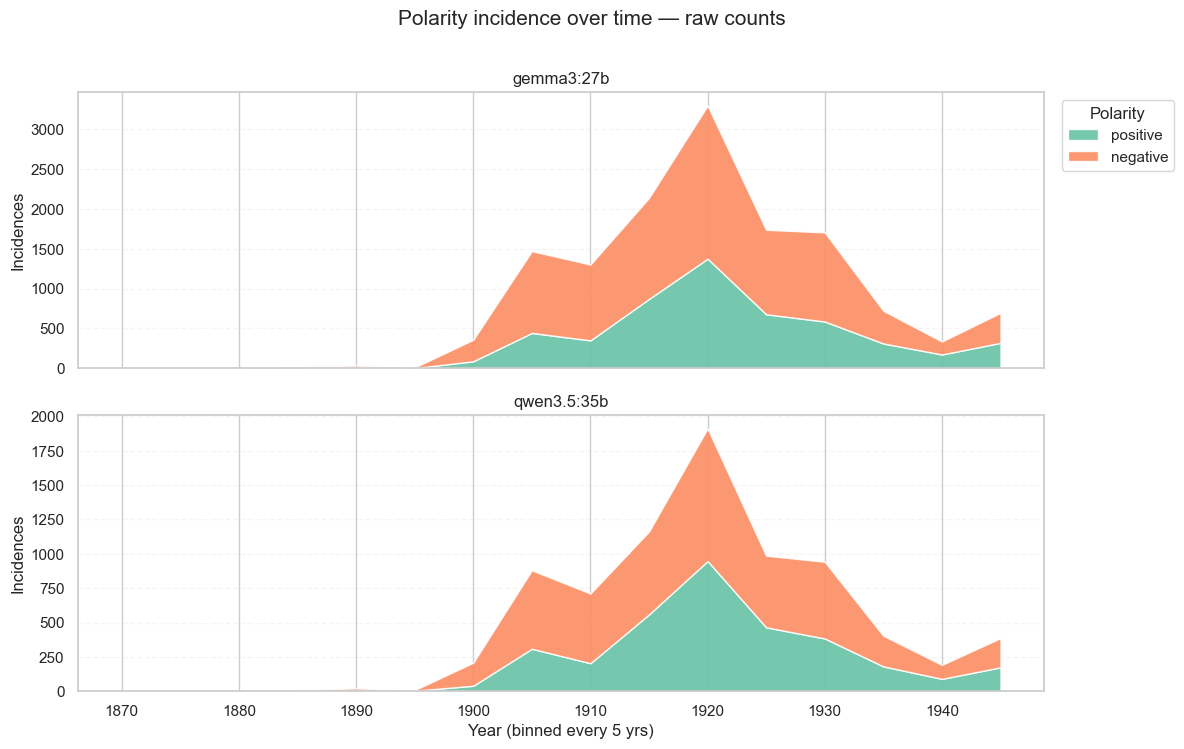

In [64]:
# ============================================================
# 2. STACKED AREA — RAW COUNTS
# ============================================================

if has_time:

    n_models = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_models,
        1,
        figsize=(12, 3.7 * n_models),
        sharex=True,
        squeeze=False,
    )

    axes = axes[:, 0]

    for ax, model in zip(axes, MODEL_ORDER):

        sub = dated[dated["model"] == model]

        pivot = (
            sub.groupby(
                ["year_bin", "polarity"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                columns=POLARITY_ORDER,
                fill_value=0
            )
            .reindex(
                year_bins,
                fill_value=0
            )
        )

        if pivot.to_numpy().sum() == 0:
            ax.set_title(f"{model} — no dated rows")
            continue

        ax.stackplot(
            pivot.index,
            *[
                pivot[p]
                for p in POLARITY_ORDER
            ],
            labels=POLARITY_ORDER,
            colors=[
                polarity_colors[p]
                for p in POLARITY_ORDER
            ],
            alpha=0.9,
        )

        ax.set_title(str(model))
        ax.set_ylabel("Incidences")

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.2,
        )

    axes[-1].set_xlabel(
        f"Year (binned every {TIME_BIN_YEARS} yrs)"
    )

    axes[0].legend(
        title="Polarity",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
    )

    fig.suptitle(
        "Polarity incidence over time — raw counts",
        fontsize=15,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()

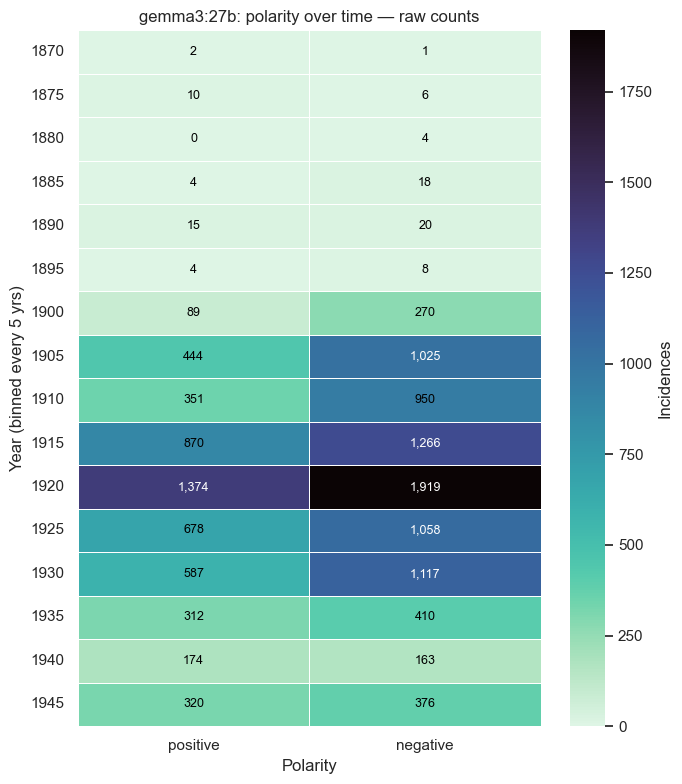

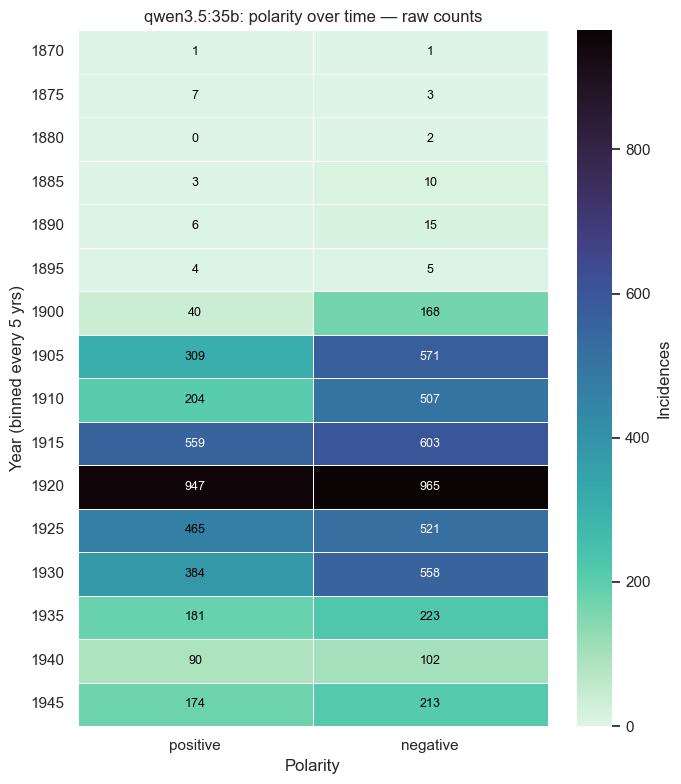

In [65]:
# ============================================================
# 3. HEATMAP — RAW COUNTS
# ============================================================

if has_time:

    for model in MODEL_ORDER:

        sub = dated[dated["model"] == model]

        pivot = (
            sub.groupby(
                ["year_bin", "polarity"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                columns=POLARITY_ORDER,
                fill_value=0
            )
            .reindex(
                year_bins,
                fill_value=0
            )
        )

        if pivot.to_numpy().sum() == 0:
            continue

        n_rows, n_cols = pivot.shape

        fig, ax = plt.subplots(
            figsize=(
                max(7, 2.0 * n_cols),
                max(5, 0.5 * n_rows),
            )
        )

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="mako_r",
            annot=False,
            linewidths=0.4,
            linecolor="white",
            cbar_kws={
                "label": "Incidences"
            },
        )

        # ----------------------------------------
        # Manually annotate every cell
        # ----------------------------------------

        vmax = pivot.to_numpy().max()

        for i in range(n_rows):
            for j in range(n_cols):

                value = pivot.iat[i, j]

                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:,}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color=(
                        "white"
                        if value > vmax * 0.5
                        else "black"
                    ),
                    zorder=10,
                )

        ax.set_title(
            f"{model}: polarity over time — raw counts"
        )

        ax.set_xlabel("Polarity")

        ax.set_ylabel(
            f"Year (binned every "
            f"{TIME_BIN_YEARS} yrs)"
        )

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=0,
        )

        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0,
        )

        plt.tight_layout()
        plt.show()

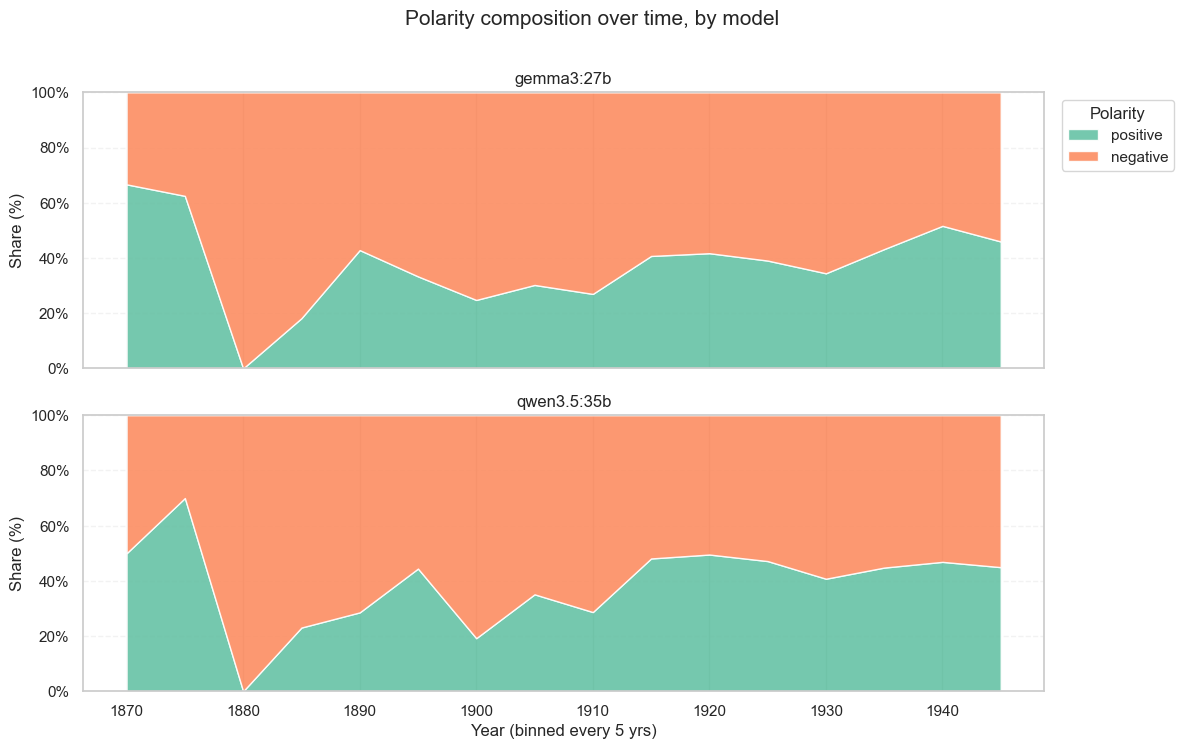

In [66]:
# ============================================================
# 4. 100% STACKED AREA — POLARITY SHARE
# ============================================================

if has_time:

    n_models = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_models,
        1,
        figsize=(12, 3.7 * n_models),
        sharex=True,
        squeeze=False,
    )

    axes = axes[:, 0]

    for ax, model in zip(axes, MODEL_ORDER):

        sub = dated[dated["model"] == model]

        # Raw counts
        pivot = (
            sub.groupby(
                ["year_bin", "polarity"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                columns=POLARITY_ORDER,
                fill_value=0
            )
            .reindex(
                year_bins,
                fill_value=0
            )
        )

        if pivot.to_numpy().sum() == 0:
            ax.set_title(f"{model} — no dated rows")
            continue

        # ----------------------------------------
        # Convert each year to percentages
        # ----------------------------------------

        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(
                row_totals.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )

        ax.stackplot(
            pivot_pct.index,
            *[
                pivot_pct[p]
                for p in POLARITY_ORDER
            ],
            labels=POLARITY_ORDER,
            colors=[
                polarity_colors[p]
                for p in POLARITY_ORDER
            ],
            alpha=0.9,
        )

        ax.set_title(str(model))
        ax.set_ylabel("Share (%)")
        ax.set_ylim(0, 100)

        ax.yaxis.set_major_formatter(
            mtick.PercentFormatter(xmax=100)
        )

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.25,
        )

    axes[-1].set_xlabel(
        f"Year (binned every {TIME_BIN_YEARS} yrs)"
    )

    axes[0].legend(
        title="Polarity",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
    )

    fig.suptitle(
        "Polarity composition over time, by model",
        fontsize=15,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()

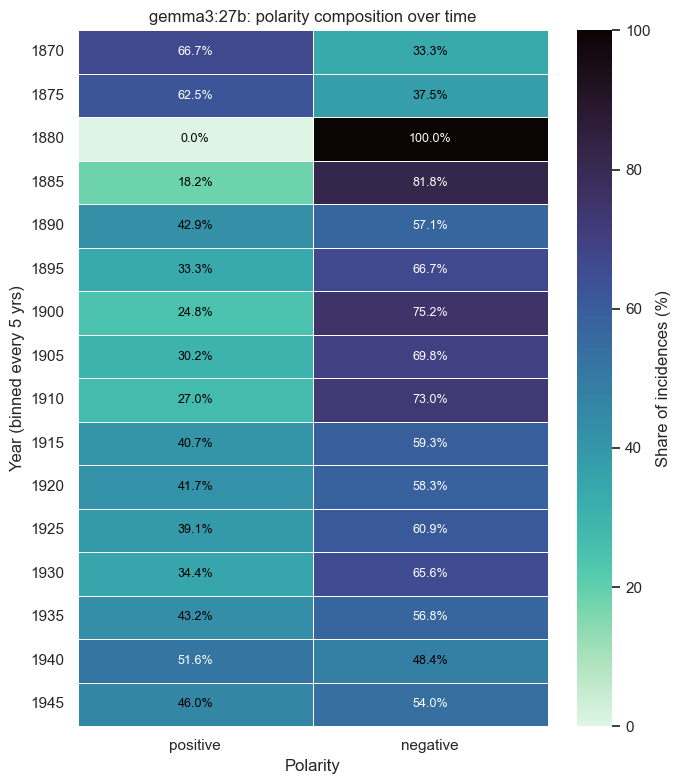

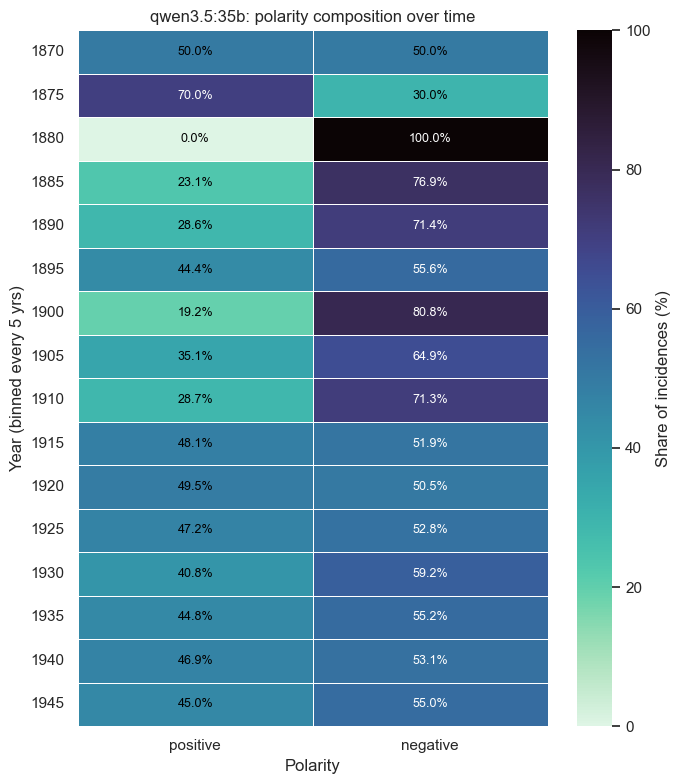

In [67]:
# ============================================================
# 5. HEATMAP — POLARITY SHARE (%)
# ============================================================

if has_time:

    for model in MODEL_ORDER:

        sub = dated[dated["model"] == model]

        # Raw counts
        pivot = (
            sub.groupby(
                ["year_bin", "polarity"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                columns=POLARITY_ORDER,
                fill_value=0
            )
            .reindex(
                year_bins,
                fill_value=0
            )
        )

        if pivot.to_numpy().sum() == 0:
            continue

        # Convert each year row to percentages
        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(
                row_totals.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )

        n_rows, n_cols = pivot_pct.shape

        fig, ax = plt.subplots(
            figsize=(
                max(7, 2.0 * n_cols),
                max(5, 0.5 * n_rows),
            )
        )

        sns.heatmap(
            pivot_pct,
            ax=ax,
            cmap="mako_r",
            annot=False,
            vmin=0,
            vmax=100,
            linewidths=0.4,
            linecolor="white",
            cbar_kws={
                "label": "Share of incidences (%)"
            },
        )

        # Manually annotate every cell
        for i in range(n_rows):
            for j in range(n_cols):

                value = pivot_pct.iat[i, j]

                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color=(
                        "white"
                        if value > 50
                        else "black"
                    ),
                    zorder=10,
                )

        ax.set_title(
            f"{model}: polarity composition over time"
        )

        ax.set_xlabel("Polarity")

        ax.set_ylabel(
            f"Year (binned every {TIME_BIN_YEARS} yrs)"
        )

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=0,
        )

        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0,
        )

        plt.tight_layout()
        plt.show()

## Frame and polarity over time

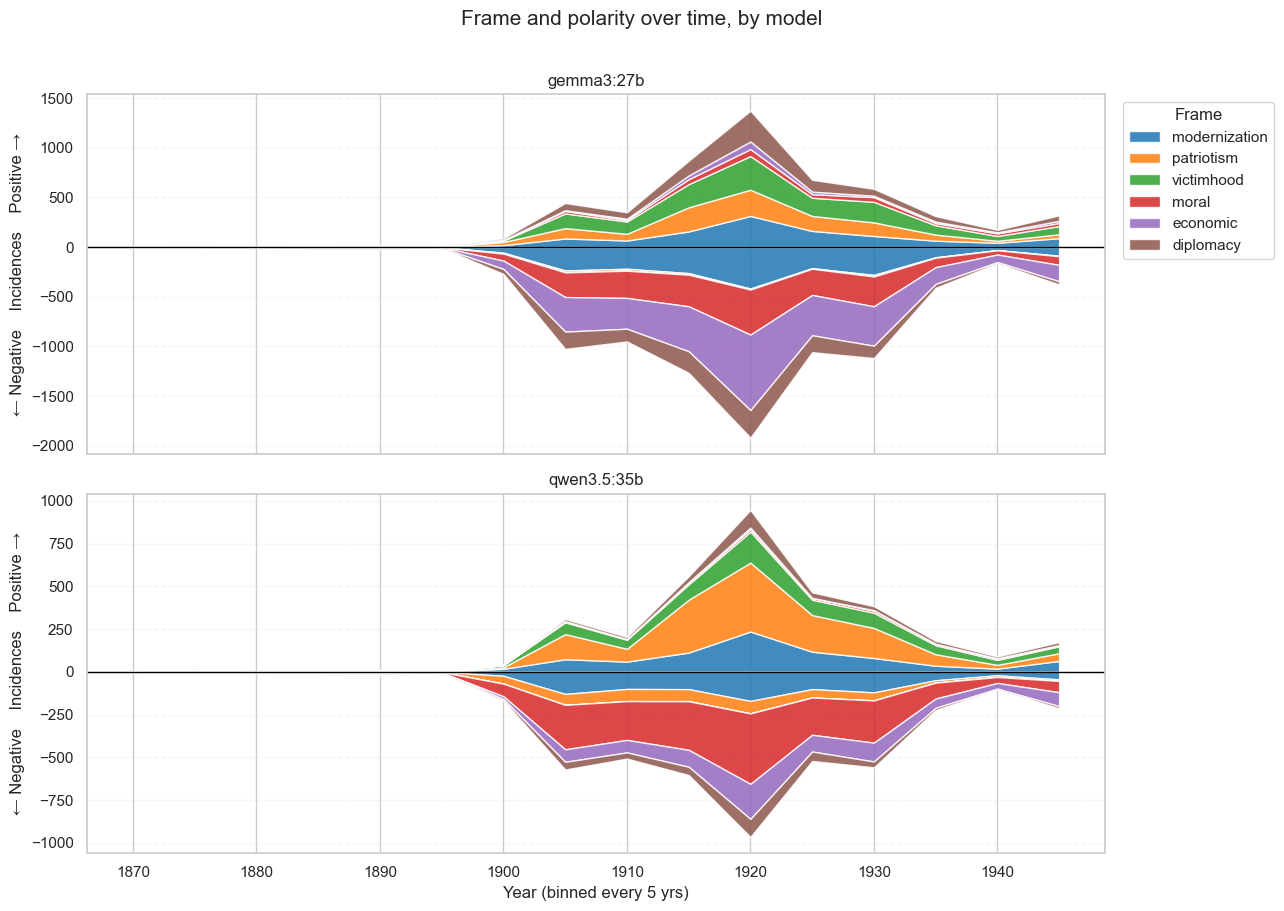

In [87]:
# ============================================================
# DIVERGING FRAME × POLARITY OVER TIME
# ============================================================

palette = sns.color_palette(
    "tab10",
    n_colors=len(FRAME_NAMES)
)

frame_colors = dict(
    zip(FRAME_NAMES, palette)
)

n_models = len(MODEL_ORDER)

fig, axes = plt.subplots(
    n_models,
    1,
    figsize=(13, 4.5 * n_models),
    sharex=True,
    squeeze=False
)

axes = axes[:, 0]


for ax, model in zip(
    axes,
    MODEL_ORDER
):

    sub = dated[
        dated["model"] == model
    ]

    # -----------------------------------------
    # POSITIVE
    # -----------------------------------------

    positive = (
        sub[
            sub["polarity"] == "positive"
        ]
        .groupby(
            ["year_bin", "frame_name"],
            observed=True
        )
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=year_bins,
            columns=FRAME_NAMES,
            fill_value=0
        )
    )

    # -----------------------------------------
    # NEGATIVE
    # -----------------------------------------

    negative = (
        sub[
            sub["polarity"] == "negative"
        ]
        .groupby(
            ["year_bin", "frame_name"],
            observed=True
        )
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=year_bins,
            columns=FRAME_NAMES,
            fill_value=0
        )
    )

    # -----------------------------------------
    # Positive frames ABOVE zero
    # -----------------------------------------

    ax.stackplot(
        positive.index,
        *[
            positive[f]
            for f in FRAME_NAMES
        ],
        labels=FRAME_NAMES,
        colors=[
            frame_colors[f]
            for f in FRAME_NAMES
        ],
        alpha=.85
    )

    # -----------------------------------------
    # Negative frames BELOW zero
    # -----------------------------------------

    ax.stackplot(
        negative.index,
        *[
            -negative[f]
            for f in FRAME_NAMES
        ],
        colors=[
            frame_colors[f]
            for f in FRAME_NAMES
        ],
        alpha=.85
    )

    # Zero line
    ax.axhline(
        0,
        color="black",
        linewidth=1
    )

    ax.set_title(str(model))

    ax.set_ylabel(
        "← Negative    Incidences    Positive →"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=.2
    )


axes[-1].set_xlabel(
    f"Year (binned every {TIME_BIN_YEARS} yrs)"
)

axes[0].legend(
    title="Frame",
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

fig.suptitle(
    "Frame and polarity over time, by model",
    fontsize=15,
    y=1.01
)

plt.tight_layout()
plt.show()

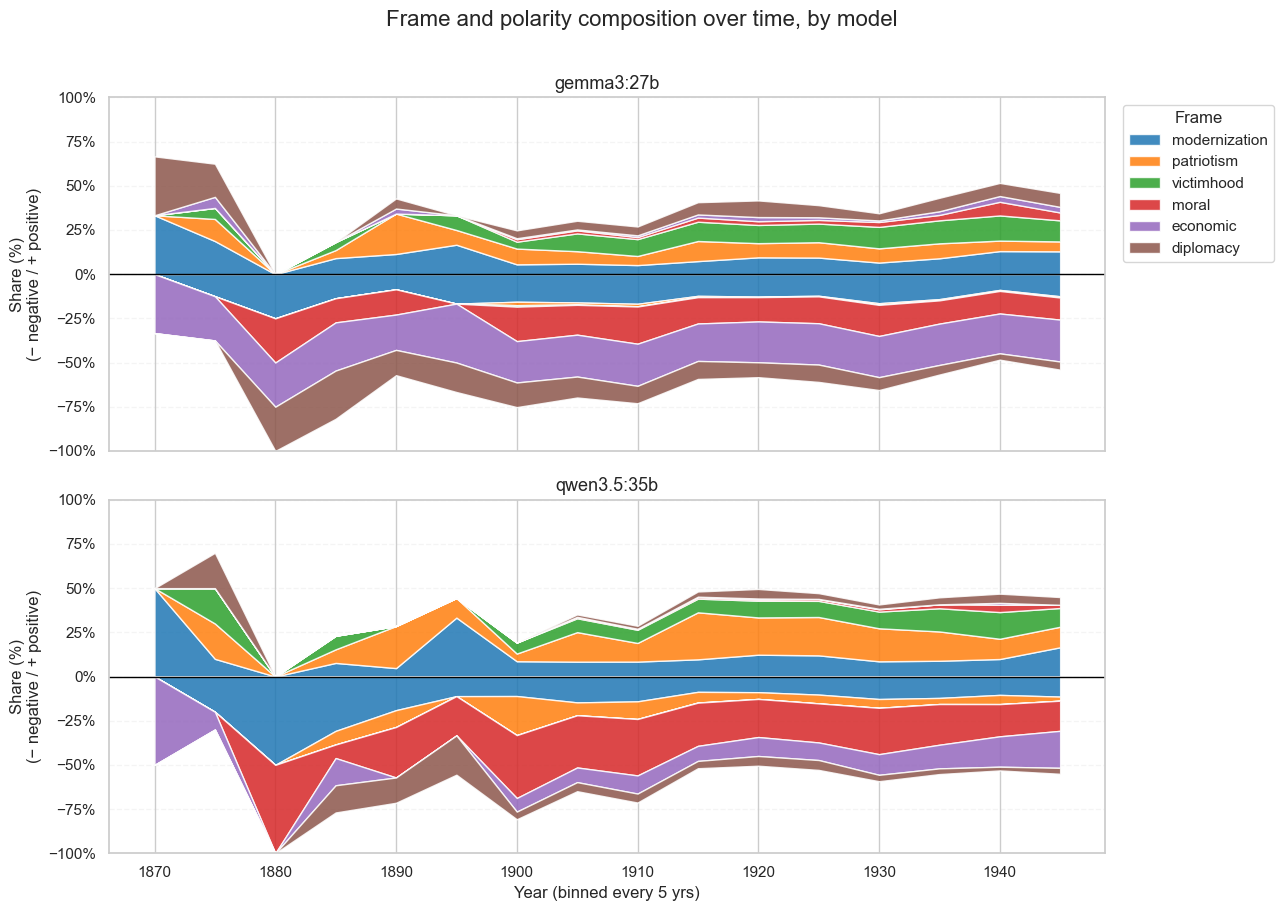

In [90]:
# ============================================================
# DIVERGING FRAME × POLARITY OVER TIME — NORMALIZED SHARES
# Positive above 0, negative below 0
# One subplot per model
# ============================================================


# Consistent frame colors across models
palette = sns.color_palette(
    "tab10",
    n_colors=len(FRAME_NAMES)
)

frame_colors = dict(
    zip(FRAME_NAMES, palette)
)


if has_time:

    n_models = len(MODEL_ORDER)

    # --------------------------------------------------------
    # Create figure and axes
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        n_models,
        1,
        figsize=(13, 4.5 * n_models),
        sharex=True,
        squeeze=False
    )

    axes = axes[:, 0]


    # --------------------------------------------------------
    # One panel per model
    # --------------------------------------------------------

    for ax, model in zip(
        axes,
        MODEL_ORDER
    ):

        sub = dated[
            dated["model"] == model
        ]


        # ====================================================
        # Positive counts
        # ====================================================

        positive = (
            sub[
                sub["polarity"] == "positive"
            ]
            .groupby(
                ["year_bin", "frame_name"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                index=year_bins,
                columns=FRAME_NAMES,
                fill_value=0
            )
        )


        # ====================================================
        # Negative counts
        # ====================================================

        negative = (
            sub[
                sub["polarity"] == "negative"
            ]
            .groupby(
                ["year_bin", "frame_name"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                index=year_bins,
                columns=FRAME_NAMES,
                fill_value=0
            )
        )


        # ====================================================
        # Total frame incidences per year
        # ====================================================

        total = (
            positive.sum(axis=1)
            + negative.sum(axis=1)
        )


        # ====================================================
        # Convert to share of ALL frame incidences that year
        # ====================================================

        positive_pct = (
            positive
            .div(
                total.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )

        negative_pct = (
            negative
            .div(
                total.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )


        # ====================================================
        # Positive frames ABOVE zero
        # ====================================================

        ax.stackplot(
            positive_pct.index,
            *[
                positive_pct[f]
                for f in FRAME_NAMES
            ],
            labels=FRAME_NAMES,
            colors=[
                frame_colors[f]
                for f in FRAME_NAMES
            ],
            alpha=0.85
        )


        # ====================================================
        # Negative frames BELOW zero
        # ====================================================

        ax.stackplot(
            negative_pct.index,
            *[
                -negative_pct[f]
                for f in FRAME_NAMES
            ],
            colors=[
                frame_colors[f]
                for f in FRAME_NAMES
            ],
            alpha=0.85
        )


        # Zero/reference line
        ax.axhline(
            0,
            color="black",
            linewidth=1
        )


        # Same y-axis scale for all models
        ax.set_ylim(
            -100,
            100
        )

        ax.set_title(
            str(model),
            fontsize=13
        )

        ax.set_ylabel(
            "Share (%)\n"
            "(− negative / + positive)"
        )

        ax.yaxis.set_major_formatter(
            mtick.PercentFormatter(
                xmax=100
            )
        )

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.2
        )


    # ========================================================
    # X-axis
    # ========================================================

    axes[-1].set_xlabel(
        f"Year (binned every {TIME_BIN_YEARS} yrs)"
    )


    # ========================================================
    # One common legend
    # ========================================================

    axes[0].legend(
        title="Frame",
        loc="upper left",
        bbox_to_anchor=(1.01, 1)
    )


    # ========================================================
    # Overall title
    # ========================================================

    fig.suptitle(
        "Frame and polarity composition over time, by model",
        fontsize=16,
        y=1.01
    )

    plt.tight_layout()

    plt.show()

In [94]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px


# ============================================================
# INTERACTIVE DIVERGING FRAME × POLARITY OVER TIME
# Positive above 0, negative below 0
# Values = share of ALL frame incidences in each year
# ============================================================

if has_time:

    n_models = len(MODEL_ORDER)

    # --------------------------------------------------------
    # Create subplots
    # --------------------------------------------------------

    fig = make_subplots(
        rows=n_models,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        subplot_titles=[str(model) for model in MODEL_ORDER]
    )


    # --------------------------------------------------------
    # Consistent colors for frames
    # --------------------------------------------------------

    palette = px.colors.qualitative.Plotly

    frame_colors = {
        frame: palette[i % len(palette)]
        for i, frame in enumerate(FRAME_NAMES)
    }


    # --------------------------------------------------------
    # One row per model
    # --------------------------------------------------------

    for row, model in enumerate(MODEL_ORDER, start=1):

        sub = dated[
            dated["model"] == model
        ]


        # ====================================================
        # Positive counts
        # ====================================================

        positive = (
            sub[
                sub["polarity"] == "positive"
            ]
            .groupby(
                ["year_bin", "frame_name"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                index=year_bins,
                columns=FRAME_NAMES,
                fill_value=0
            )
        )


        # ====================================================
        # Negative counts
        # ====================================================

        negative = (
            sub[
                sub["polarity"] == "negative"
            ]
            .groupby(
                ["year_bin", "frame_name"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                index=year_bins,
                columns=FRAME_NAMES,
                fill_value=0
            )
        )


        # ====================================================
        # Total incidences per year
        # ====================================================

        total = (
            positive.sum(axis=1)
            + negative.sum(axis=1)
        )


        # ====================================================
        # Normalize as share of ALL incidences that year
        # ====================================================

        positive_pct = (
            positive
            .div(
                total.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )

        negative_pct = (
            negative
            .div(
                total.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )


        # ====================================================
        # POSITIVE — above zero
        # ====================================================

        for frame in FRAME_NAMES:

            fig.add_trace(
                go.Scatter(
                    x=positive_pct.index,
                    y=positive_pct[frame],

                    name=frame,

                    legendgroup=frame,

                    # positive stack
                    stackgroup=f"positive_{row}",

                    mode="lines",

                    line=dict(
                        width=0.5,
                        color=frame_colors[frame]
                    ),

                    fillcolor=frame_colors[frame],

                    # Show each frame only once in legend
                    showlegend=(row == 1),

                    hovertemplate=(
                        f"<b>{frame}</b><br>"
                        "Polarity: positive<br>"
                        "Year: %{x}<br>"
                        "Share: %{y:.1f}%"
                        "<extra></extra>"
                    ),
                ),
                row=row,
                col=1
            )


        # ====================================================
        # NEGATIVE — below zero
        # ====================================================

        for frame in FRAME_NAMES:

            fig.add_trace(
                go.Scatter(
                    x=negative_pct.index,

                    # important: negative values
                    y=-negative_pct[frame],

                    name=frame,

                    legendgroup=frame,

                    # separate negative stack
                    stackgroup=f"negative_{row}",

                    mode="lines",

                    line=dict(
                        width=0.5,
                        color=frame_colors[frame]
                    ),

                    fillcolor=frame_colors[frame],

                    # No duplicate legend entries
                    showlegend=False,

                    hovertemplate=(
                        f"<b>{frame}</b><br>"
                        "Polarity: negative<br>"
                        "Year: %{x}<br>"
                        "Share: %{customdata:.1f}%"
                        "<extra></extra>"
                    ),

                    # show positive percentage in tooltip
                    customdata=negative_pct[frame]
                ),
                row=row,
                col=1
            )


        # ====================================================
        # Zero line
        # ====================================================

        fig.add_hline(
            y=0,
            line_width=1,
            line_color="black",
            row=row,
            col=1
        )


        # ====================================================
        # Y-axis
        # ====================================================

        fig.update_yaxes(
            title_text=(
                "Share (%)<br>"
                "− negative / + positive"
            ),
            range=[-100, 100],
            ticksuffix="%",
            row=row,
            col=1
        )


    # ========================================================
    # X-axis
    # ========================================================

    fig.update_xaxes(
        title_text=(
            f"Year (binned every {TIME_BIN_YEARS} yrs)"
        ),
        row=n_models,
        col=1
    )


    # ========================================================
    # Overall layout
    # ========================================================

    fig.update_layout(

    title=dict(
        text=(
            "Frame and polarity composition over time, "
            "by model"
        ),
        x=0.5
    ),

    height=420 * n_models,
    width=1250,

    # Avoid duplicated positive/negative tooltip entries
    hovermode="closest",

    legend=dict(
        title="Frame",
        orientation="v",
        x=1.02,
        y=1
    ),

    margin=dict(
        l=90,
        r=220,
        t=100,
        b=70
    )
)


    # ========================================================
    # Display interactively
    # ========================================================

    fig.show()


    # ========================================================
    # Export standalone HTML
    # ========================================================

    fig.write_html(
        "frame_polarity_over_time_interactive.html",
        include_plotlyjs=True
    )

## Association between frames

In [97]:
# ============================================================
# CREATE UNIQUE SEGMENT ID
# ============================================================

exploded["segment_id"] = (
    exploded["doc_id"].astype(str)
    + "_"
    + exploded["segment_index"].astype(str)
)

# Quick checks
print("Documents:", exploded["doc_id"].nunique())
print("Segments:", exploded["segment_id"].nunique())
print("Rows:", len(exploded))

exploded[
    ["doc_id", "segment_index", "segment_id"]
].head()

Documents: 4363
Segments: 4580
Rows: 21686


,doc_id,segment_index,segment_id
0,SPSP192503251204,1,SPSP192503251204_1
1,SPSP192712211406,1,SPSP192712211406_1
1,SPSP192712211406,1,SPSP192712211406_1
1,SPSP192712211406,1,SPSP192712211406_1
2,SPSP192409120704,1,SPSP192409120704_1


In [98]:
from itertools import combinations
from collections import Counter

ID_COL = "segment_id"

def frame_cooccurrence(df, id_col="segment_id"):

    pairs = Counter()

    for _, group in df.groupby(id_col):

        # Unique frames within this segment
        frames = sorted(
            set(
                group["frame_name"]
                .dropna()
                .astype(str)
            )
        )

        # All unique frame pairs
        for frame_a, frame_b in combinations(frames, 2):
            pairs[(frame_a, frame_b)] += 1

    # Create symmetric matrix
    matrix = pd.DataFrame(
        0,
        index=FRAME_NAMES,
        columns=FRAME_NAMES,
        dtype=int
    )

    for (frame_a, frame_b), count in pairs.items():

        if (
            frame_a in matrix.index
            and frame_b in matrix.columns
        ):
            matrix.loc[frame_a, frame_b] = count
            matrix.loc[frame_b, frame_a] = count

    return matrix

In [99]:
cooc = frame_cooccurrence(
    exploded,
    id_col="segment_id"
)

print(cooc)

               modernization  patriotism  victimhood  moral  economic  \
modernization              0        1361         685   1994      2495   
patriotism              1361           0         769   1301      1473   
victimhood               685         769           0   1033      1116   
moral                   1994        1301        1033      0      2289   
economic                2495        1473        1116   2289         0   
diplomacy               1390        1293         738   1138      1653   

               diplomacy  
modernization       1390  
patriotism          1293  
victimhood           738  
moral               1138  
economic            1653  
diplomacy              0  


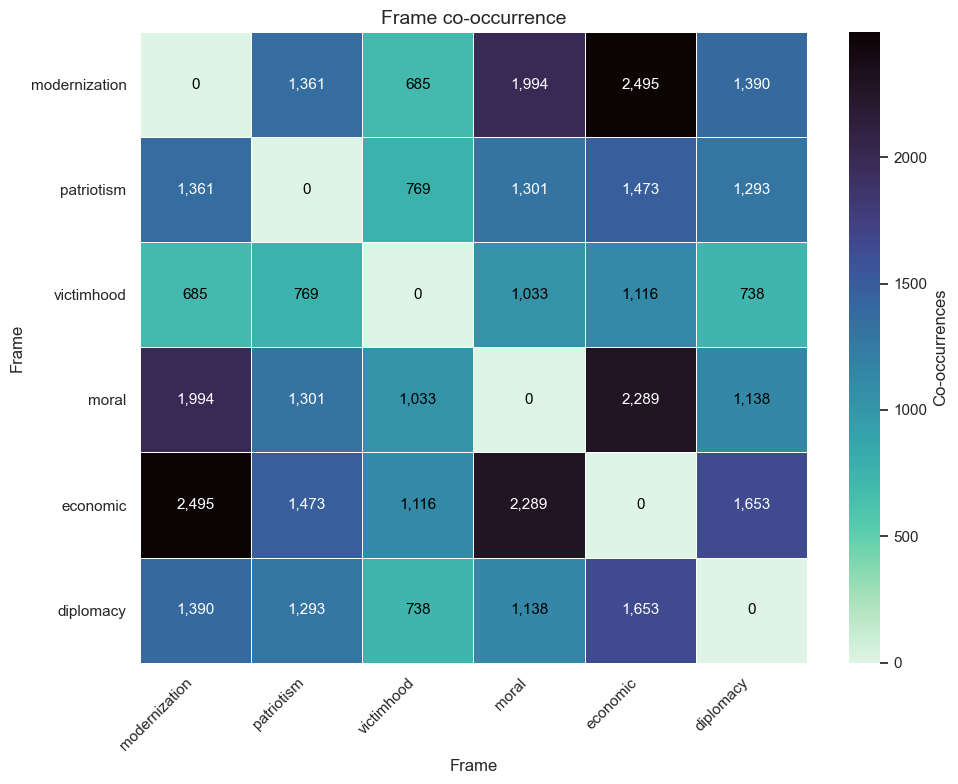

In [106]:
fig, ax = plt.subplots(figsize=(10, 8))

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

sns.heatmap(
    cooc,
    cmap="mako_r",
    annot=False,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Co-occurrences"
    },
    xticklabels=False,
    yticklabels=False,
    ax=ax
)


# ------------------------------------------------------------
# Manually annotate EVERY cell
# ------------------------------------------------------------

n_rows, n_cols = cooc.shape

# Used to decide whether text should be white or black
max_value = cooc.to_numpy().max()

for i in range(n_rows):
    for j in range(n_cols):

        value = cooc.iat[i, j]

        # Dark cells -> white text
        # Light cells -> black text
        text_color = (
            "white"
            if value > max_value * 0.50
            else "black"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{int(value):,}",
            ha="center",
            va="center",
            fontsize=11,
            color=text_color,
            zorder=10,
            clip_on=False
        )


# ------------------------------------------------------------
# Explicitly restore ALL axis labels
# ------------------------------------------------------------

ax.set_yticks(
    np.arange(n_rows) + 0.5
)

ax.set_yticklabels(
    cooc.index,
    rotation=0,
    fontsize=11
)

ax.set_xticks(
    np.arange(n_cols) + 0.5
)

ax.set_xticklabels(
    cooc.columns,
    rotation=45,
    ha="right",
    fontsize=11
)


# ------------------------------------------------------------
# Explicitly restore full heatmap extent
# ------------------------------------------------------------

ax.set_xlim(
    0,
    n_cols
)

ax.set_ylim(
    n_rows,
    0
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_title(
    "Frame co-occurrence",
    fontsize=14
)

ax.set_xlabel(
    "Frame",
    fontsize=12
)

ax.set_ylabel(
    "Frame",
    fontsize=12
)

plt.tight_layout()
plt.show()

In [107]:
cooc_by_model = {}

for model in MODEL_ORDER:

    sub = exploded[
        exploded["model"] == model
    ]

    cooc_by_model[model] = frame_cooccurrence(
        sub,
        id_col="segment_id"
    )

    print(f"\n{model}")
    print(cooc_by_model[model])


gemma3:27b
               modernization  patriotism  victimhood  moral  economic  \
modernization              0         808         585   1604      2408   
patriotism               808           0         369    503       800   
victimhood               585         369           0    833      1029   
moral                   1604         503         833      0      1930   
economic                2408         800        1029   1930         0   
diplomacy               1326         654         676    811      1621   

               diplomacy  
modernization       1326  
patriotism           654  
victimhood           676  
moral                811  
economic            1621  
diplomacy              0  

qwen3.5:35b
               modernization  patriotism  victimhood  moral  economic  \
modernization              0         416          67    577       393   
patriotism               416           0         240    841       187   
victimhood                67         240           0   

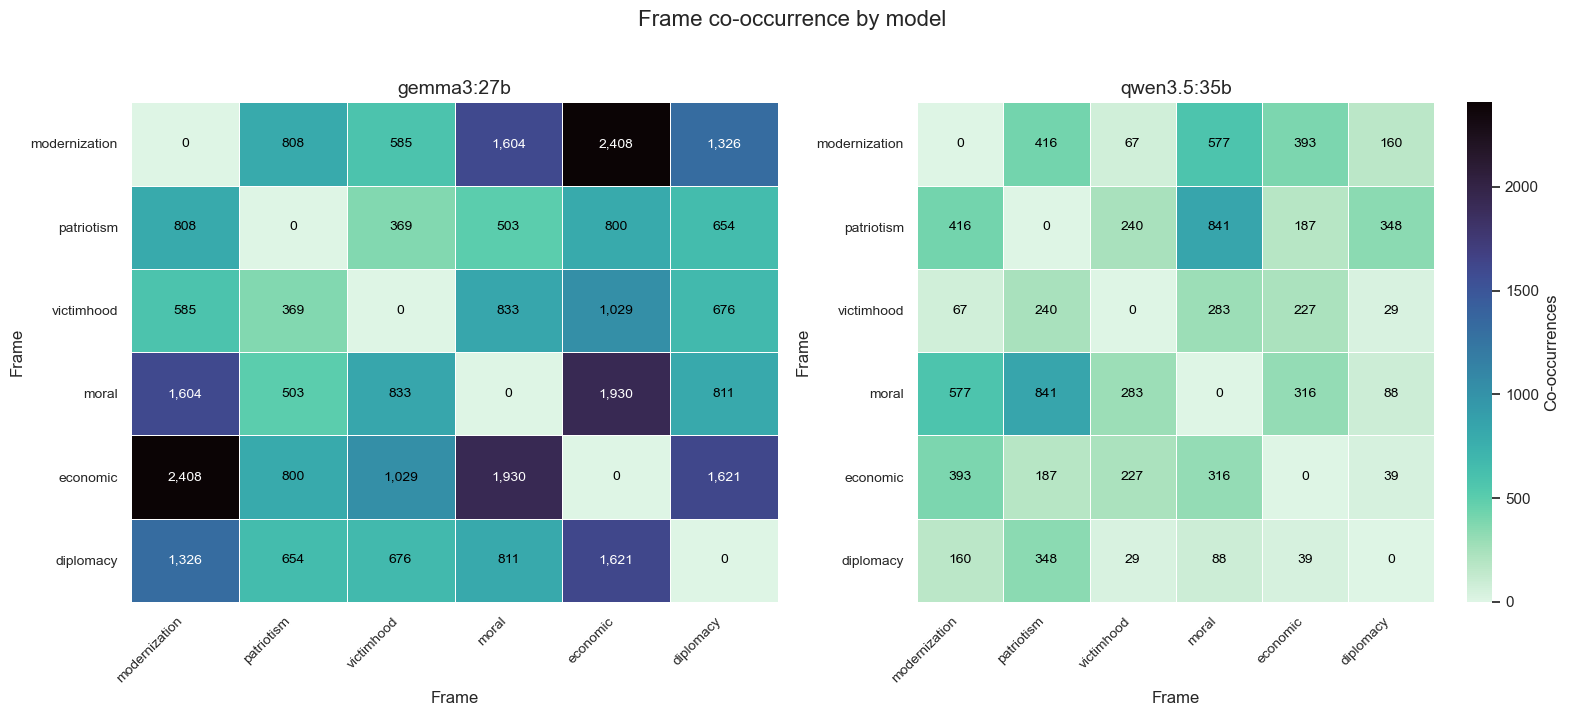

In [108]:
# ============================================================
# FRAME CO-OCCURRENCE BY MODEL
# SIDE-BY-SIDE HEATMAPS
# ============================================================

models_to_plot = [
    model for model in MODEL_ORDER
    if model in cooc_by_model
]

# Common color scale across models
global_max = max(
    cooc_by_model[model].to_numpy().max()
    for model in models_to_plot
)

n_models = len(models_to_plot)

fig, axes = plt.subplots(
    1,
    n_models,
    figsize=(8 * n_models, 7),
    sharey=False,
    squeeze=False
)

axes = axes[0]


for idx, (ax, model) in enumerate(
    zip(axes, models_to_plot)
):

    cooc = cooc_by_model[model]

    n_rows, n_cols = cooc.shape

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    sns.heatmap(
        cooc,
        ax=ax,
        cmap="mako_r",
        annot=False,

        # Same scale across models
        vmin=0,
        vmax=global_max,

        linewidths=0.5,
        linecolor="white",

        xticklabels=False,
        yticklabels=False,

        # One colorbar only, on final panel
        cbar=(idx == n_models - 1),

        cbar_kws={
            "label": "Co-occurrences"
        } if idx == n_models - 1 else None
    )


    # --------------------------------------------------------
    # Manually annotate EVERY cell
    # --------------------------------------------------------

    for i in range(n_rows):
        for j in range(n_cols):

            value = cooc.iat[i, j]

            # Adapt text color to cell intensity
            text_color = (
                "white"
                if value > global_max * 0.50
                else "black"
            )

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{int(value):,}",
                ha="center",
                va="center",
                fontsize=10,
                color=text_color,
                zorder=10,
                clip_on=False
            )


    # --------------------------------------------------------
    # Restore frame labels explicitly
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(n_cols) + 0.5
    )

    ax.set_xticklabels(
        cooc.columns,
        rotation=45,
        ha="right",
        fontsize=10
    )

    ax.set_yticks(
        np.arange(n_rows) + 0.5
    )

    ax.set_yticklabels(
        cooc.index,
        rotation=0,
        fontsize=10
    )


    # --------------------------------------------------------
    # Preserve full matrix
    # --------------------------------------------------------

    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)


    # --------------------------------------------------------
    # Titles
    # --------------------------------------------------------

    ax.set_title(
        str(model),
        fontsize=14
    )

    ax.set_xlabel("Frame")
    ax.set_ylabel("Frame")


fig.suptitle(
    "Frame co-occurrence by model",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [109]:
# ============================================================
# JACCARD SIMILARITY BETWEEN FRAMES
# Unit of analysis = segment
# ============================================================

import numpy as np
import pandas as pd


def frame_jaccard(
    df,
    id_col="segment_id",
    frame_col="frame_name"
):

    # --------------------------------------------------------
    # Segment × frame presence/absence matrix
    # --------------------------------------------------------

    binary = (
        df.assign(present=1)
        .pivot_table(
            index=id_col,
            columns=frame_col,
            values="present",
            aggfunc="max",
            fill_value=0
        )
        .reindex(
            columns=FRAME_NAMES,
            fill_value=0
        )
        .astype(bool)
    )


    # --------------------------------------------------------
    # Empty Jaccard matrix
    # --------------------------------------------------------

    matrix = pd.DataFrame(
        np.nan,
        index=FRAME_NAMES,
        columns=FRAME_NAMES,
        dtype=float
    )


    # --------------------------------------------------------
    # Calculate pairwise Jaccard similarity
    # --------------------------------------------------------

    for frame_a in FRAME_NAMES:

        for frame_b in FRAME_NAMES:

            A = binary[frame_a]
            B = binary[frame_b]

            intersection = (
                A & B
            ).sum()

            union = (
                A | B
            ).sum()

            matrix.loc[
                frame_a,
                frame_b
            ] = (
                intersection / union
                if union > 0
                else np.nan
            )

    return matrix

In [110]:
jaccard_overall = frame_jaccard(
    exploded,
    id_col="segment_id"
)

print(
    jaccard_overall.round(3)
)

               modernization  patriotism  victimhood  moral  economic  \
modernization          1.000       0.351       0.170  0.493     0.613   
patriotism             0.351       1.000       0.264  0.350     0.362   
victimhood             0.170       0.264       1.000  0.300     0.287   
moral                  0.493       0.350       0.300  1.000     0.565   
economic               0.613       0.362       0.287  0.565     1.000   
diplomacy              0.352       0.427       0.242  0.286     0.414   

               diplomacy  
modernization      0.352  
patriotism         0.427  
victimhood         0.242  
moral              0.286  
economic           0.414  
diplomacy          1.000  


In [111]:
jaccard_by_model = {}

for model in MODEL_ORDER:

    sub = exploded[
        exploded["model"] == model
    ]

    jaccard_by_model[model] = frame_jaccard(
        sub,
        id_col="segment_id"
    )

    print(
        f"\n{model}"
    )

    print(
        jaccard_by_model[model]
        .round(3)
    )


gemma3:27b
               modernization  patriotism  victimhood  moral  economic  \
modernization          1.000       0.233       0.148  0.409     0.595   
patriotism             0.233       1.000       0.157  0.157     0.208   
victimhood             0.148       0.157       1.000  0.265     0.266   
moral                  0.409       0.157       0.265  1.000     0.486   
economic               0.595       0.208       0.266  0.486     1.000   
diplomacy              0.341       0.238       0.226  0.210     0.408   

               diplomacy  
modernization      0.341  
patriotism         0.238  
victimhood         0.226  
moral              0.210  
economic           0.408  
diplomacy          1.000  

qwen3.5:35b
               modernization  patriotism  victimhood  moral  economic  \
modernization          1.000       0.131       0.029  0.186     0.183   
patriotism             0.131       1.000       0.100  0.273     0.072   
victimhood             0.029       0.100       1.000  0

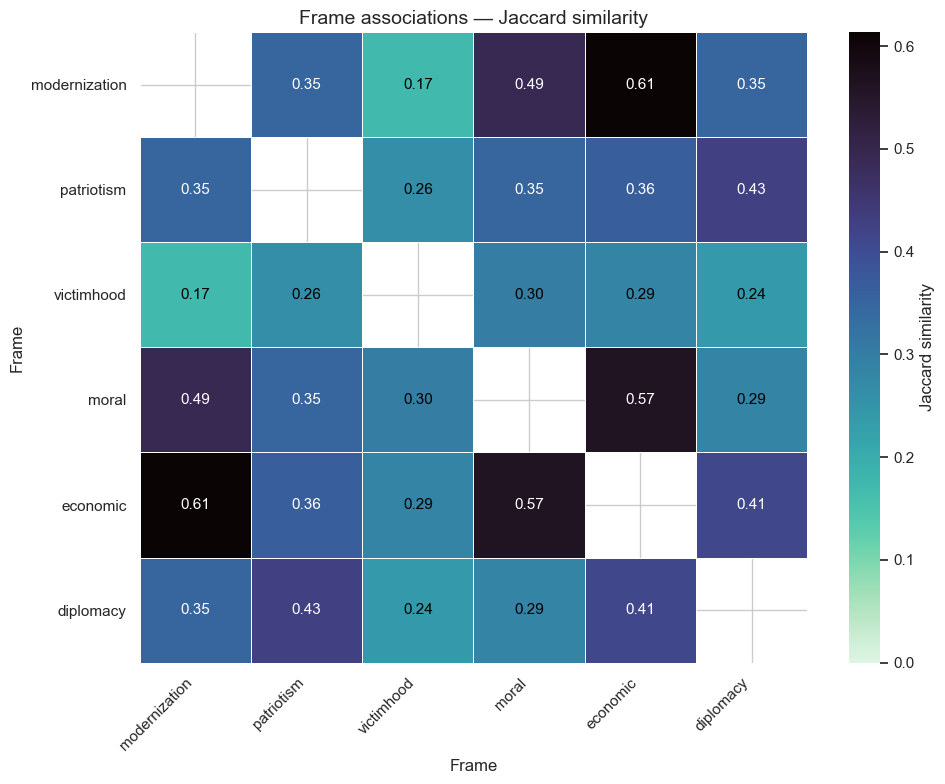

In [112]:
# ============================================================
# OVERALL JACCARD HEATMAP
# ============================================================

jaccard_plot = jaccard_overall.copy()

# Remove trivial diagonal
np.fill_diagonal(
    jaccard_plot.values,
    np.nan
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

sns.heatmap(
    jaccard_plot,
    cmap="mako_r",
    annot=False,
    vmin=0,
    vmax=np.nanmax(jaccard_plot.to_numpy()),
    linewidths=0.5,
    linecolor="white",
    xticklabels=False,
    yticklabels=False,
    cbar_kws={
        "label": "Jaccard similarity"
    },
    ax=ax
)


# ------------------------------------------------------------
# Manual annotations
# ------------------------------------------------------------

n_rows, n_cols = jaccard_plot.shape
max_value = np.nanmax(
    jaccard_plot.to_numpy()
)

for i in range(n_rows):

    for j in range(n_cols):

        value = jaccard_plot.iat[i, j]

        if pd.isna(value):
            continue

        text_color = (
            "white"
            if value > max_value * 0.50
            else "black"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color=text_color,
            zorder=10,
            clip_on=False
        )


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(n_cols) + 0.5
)

ax.set_xticklabels(
    jaccard_plot.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    np.arange(n_rows) + 0.5
)

ax.set_yticklabels(
    jaccard_plot.index,
    rotation=0
)

ax.set_xlim(0, n_cols)
ax.set_ylim(n_rows, 0)

ax.set_title(
    "Frame associations — Jaccard similarity",
    fontsize=14
)

ax.set_xlabel("Frame")
ax.set_ylabel("Frame")

plt.tight_layout()
plt.show()

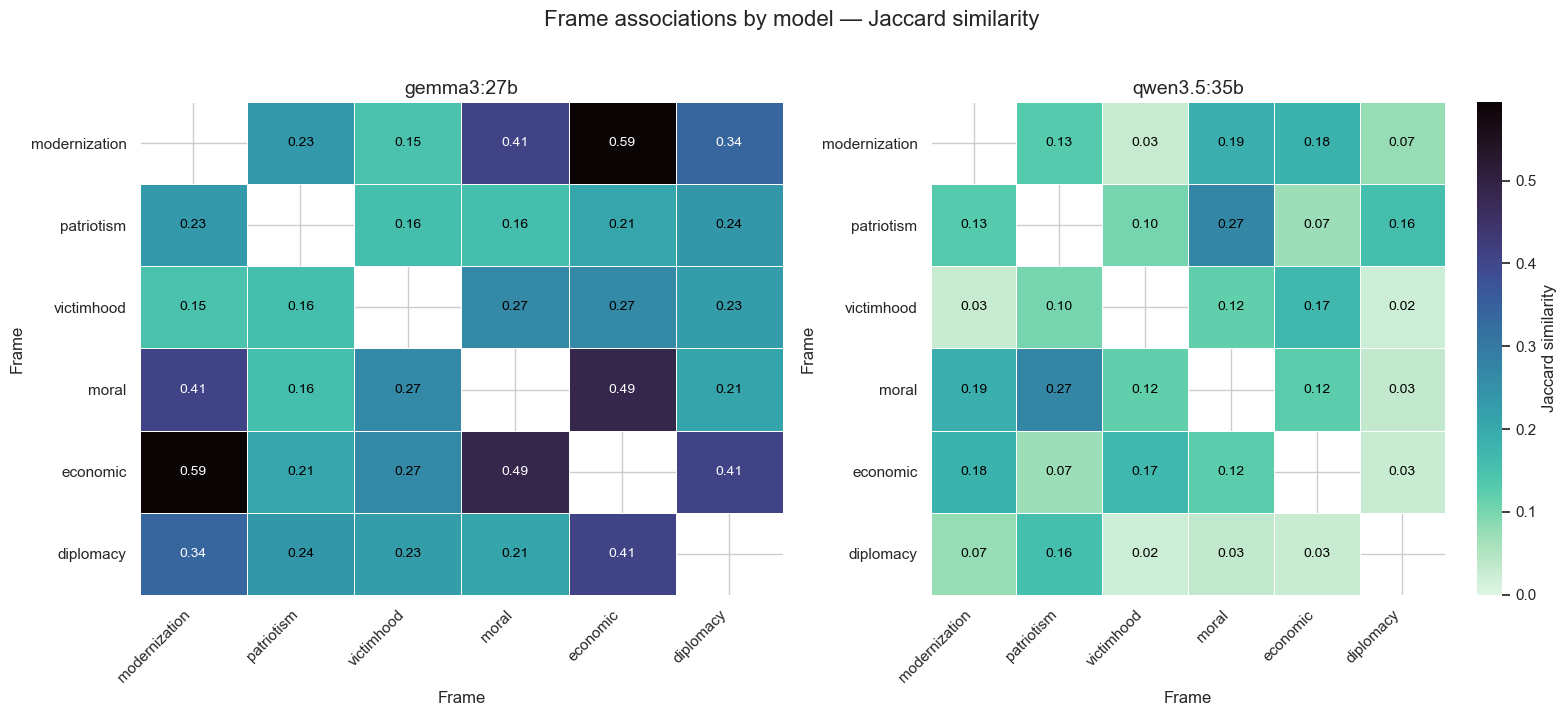

In [113]:
# ============================================================
# JACCARD SIMILARITY BY MODEL
# SIDE-BY-SIDE HEATMAPS
# ============================================================

models_to_plot = [
    model
    for model in MODEL_ORDER
    if model in jaccard_by_model
]


# ------------------------------------------------------------
# Remove diagonal for plotting
# ------------------------------------------------------------

jaccard_plot_by_model = {}

for model in models_to_plot:

    matrix = (
        jaccard_by_model[model]
        .copy()
    )

    np.fill_diagonal(
        matrix.values,
        np.nan
    )

    jaccard_plot_by_model[
        model
    ] = matrix


# ------------------------------------------------------------
# Common color scale
# ------------------------------------------------------------

global_max = max(
    np.nanmax(
        matrix.to_numpy()
    )
    for matrix
    in jaccard_plot_by_model.values()
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

n_models = len(models_to_plot)

fig, axes = plt.subplots(
    1,
    n_models,
    figsize=(8 * n_models, 7),
    sharey=False,
    squeeze=False
)

axes = axes[0]


for idx, (ax, model) in enumerate(
    zip(
        axes,
        models_to_plot
    )
):

    matrix = (
        jaccard_plot_by_model[
            model
        ]
    )

    n_rows, n_cols = (
        matrix.shape
    )


    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    sns.heatmap(
        matrix,
        ax=ax,
        cmap="mako_r",

        annot=False,

        vmin=0,
        vmax=global_max,

        linewidths=0.5,
        linecolor="white",

        xticklabels=False,
        yticklabels=False,

        cbar=(
            idx
            == n_models - 1
        ),

        cbar_kws={
            "label":
            "Jaccard similarity"
        } if idx == n_models - 1
        else None
    )


    # --------------------------------------------------------
    # Annotate every non-diagonal cell
    # --------------------------------------------------------

    for i in range(n_rows):

        for j in range(n_cols):

            value = matrix.iat[i, j]

            if pd.isna(value):
                continue

            text_color = (
                "white"
                if value
                > global_max * 0.50
                else "black"
            )

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color=text_color,
                zorder=10,
                clip_on=False
            )


    # --------------------------------------------------------
    # Explicit labels
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(n_cols)
        + 0.5
    )

    ax.set_xticklabels(
        matrix.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticks(
        np.arange(n_rows)
        + 0.5
    )

    ax.set_yticklabels(
        matrix.index,
        rotation=0
    )

    ax.set_xlim(
        0,
        n_cols
    )

    ax.set_ylim(
        n_rows,
        0
    )

    ax.set_title(
        str(model),
        fontsize=14
    )

    ax.set_xlabel(
        "Frame"
    )

    ax.set_ylabel(
        "Frame"
    )


fig.suptitle(
    "Frame associations by model — Jaccard similarity",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

How to interpret Jaccard similary? Let's take an example. In gemma's case, Jaccard(modernization, economic) = 0.59. This means that 59% of segments containing either modernization or economic contain both frames. However, Jaccard does not fully correct for the marginal prevalence of each frame. As a result, two very common frames can have relatively high Jaccard simply because both are common. Lift provides a useful corrective. 

In [115]:
# ============================================================
# LIFT BETWEEN FRAMES
# Unit of analysis = segment
# ============================================================


def frame_lift(
    df,
    id_col="segment_id",
    frame_col="frame_name"
):

    # --------------------------------------------------------
    # Segment × frame presence/absence matrix
    # --------------------------------------------------------

    binary = (
        df.assign(present=1)
        .pivot_table(
            index=id_col,
            columns=frame_col,
            values="present",
            aggfunc="max",
            fill_value=0
        )
        .reindex(
            columns=FRAME_NAMES,
            fill_value=0
        )
        .astype(bool)
    )

    n_segments = len(binary)

    # --------------------------------------------------------
    # Empty lift matrix
    # --------------------------------------------------------

    matrix = pd.DataFrame(
        np.nan,
        index=FRAME_NAMES,
        columns=FRAME_NAMES,
        dtype=float
    )

    if n_segments == 0:
        return matrix


    # --------------------------------------------------------
    # Calculate pairwise lift
    # --------------------------------------------------------

    for frame_a in FRAME_NAMES:

        for frame_b in FRAME_NAMES:

            A = binary[frame_a]
            B = binary[frame_b]

            p_a = A.mean()
            p_b = B.mean()

            p_ab = (
                A & B
            ).mean()

            expected = (
                p_a * p_b
            )

            matrix.loc[
                frame_a,
                frame_b
            ] = (
                p_ab / expected
                if expected > 0
                else np.nan
            )

    return matrix

In [116]:
lift_overall = frame_lift(
    exploded,
    id_col="segment_id"
)

print(
    lift_overall.round(2)
)

               modernization  patriotism  victimhood  moral  economic  \
modernization           1.46        0.94        0.64   1.00      1.06   
patriotism              0.94        2.17        1.06   0.97      0.93   
victimhood              0.64        1.06        2.91   1.03      0.95   
moral                   1.00        0.97        1.03   1.58      1.05   
economic                1.06        0.93        0.95   1.05      1.33   
diplomacy               0.92        1.27        0.97   0.81      1.00   

               diplomacy  
modernization       0.92  
patriotism          1.27  
victimhood          0.97  
moral               0.81  
economic            1.00  
diplomacy           2.07  


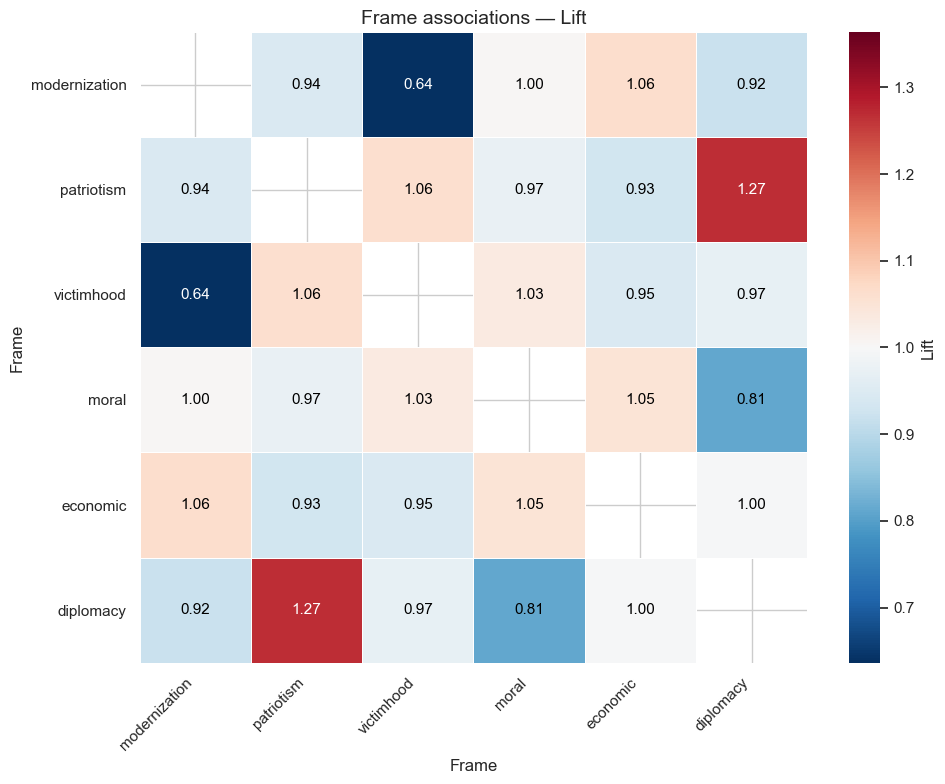

In [118]:
# ============================================================
# OVERALL LIFT HEATMAP
# ============================================================

lift_plot = lift_overall.copy()

# Diagonal is not analytically interesting
np.fill_diagonal(
    lift_plot.values,
    np.nan
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

# Symmetric color range around 1
max_deviation = np.nanmax(
    np.abs(
        lift_plot.to_numpy() - 1
    )
)

vmin = max(
    0,
    1 - max_deviation
)

vmax = (
    1 + max_deviation
)


sns.heatmap(
    lift_plot,
    cmap="RdBu_r",
    center=1,

    vmin=vmin,
    vmax=vmax,

    annot=False,

    linewidths=0.5,
    linecolor="white",

    xticklabels=False,
    yticklabels=False,

    cbar_kws={
        "label": "Lift"
    },

    ax=ax
)


# ------------------------------------------------------------
# Manual annotation
# ------------------------------------------------------------

n_rows, n_cols = (
    lift_plot.shape
)

for i in range(n_rows):

    for j in range(n_cols):

        value = lift_plot.iat[i, j]

        if pd.isna(value):
            continue

        # White text for values far from independence
        text_color = (
            "white"
            if abs(value - 1)
            > max_deviation * 0.55
            else "black"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color=text_color,
            zorder=10,
            clip_on=False
        )


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(n_cols) + 0.5
)

ax.set_xticklabels(
    lift_plot.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    np.arange(n_rows) + 0.5
)

ax.set_yticklabels(
    lift_plot.index,
    rotation=0
)

ax.set_xlim(
    0,
    n_cols
)

ax.set_ylim(
    n_rows,
    0
)

ax.set_title(
    "Frame associations — Lift",
    fontsize=14
)

ax.set_xlabel("Frame")
ax.set_ylabel("Frame")

plt.tight_layout()
plt.show()

How to interpret lift? patriotism × diplomacy = 1.27 means those two frames occur together 1.27 times as often as expected under independence, given their individual frequencies. One caution with lift: a very rare frame pair can produce a large lift from only a handful of co-occurrences. The best way is to combine the three metrics. 

In [117]:
lift_by_model = {}

for model in MODEL_ORDER:

    sub = exploded[
        exploded["model"] == model
    ]

    lift_by_model[model] = frame_lift(
        sub,
        id_col="segment_id"
    )

    print(f"\n{model}")

    print(
        lift_by_model[model]
        .round(2)
    )



gemma3:27b
               modernization  patriotism  victimhood  moral  economic  \
modernization           1.50        0.98        0.59   0.97      1.06   
patriotism              0.98        3.71        0.92   0.75      0.87   
victimhood              0.59        0.92        3.06   1.03      0.92   
moral                   0.97        0.75        1.03   1.83      1.03   
economic                1.06        0.87        0.92   1.03      1.33   
diplomacy               0.91        1.11        0.95   0.68      0.99   

               diplomacy  
modernization       0.91  
patriotism          1.11  
victimhood          0.95  
moral               0.68  
economic            0.99  
diplomacy           2.09  

qwen3.5:35b
               modernization  patriotism  victimhood  moral  economic  \
modernization           2.53        0.55        0.24   0.73      1.15   
patriotism              0.55        2.21        0.74   0.93      0.48   
victimhood              0.24        0.74        5.96   

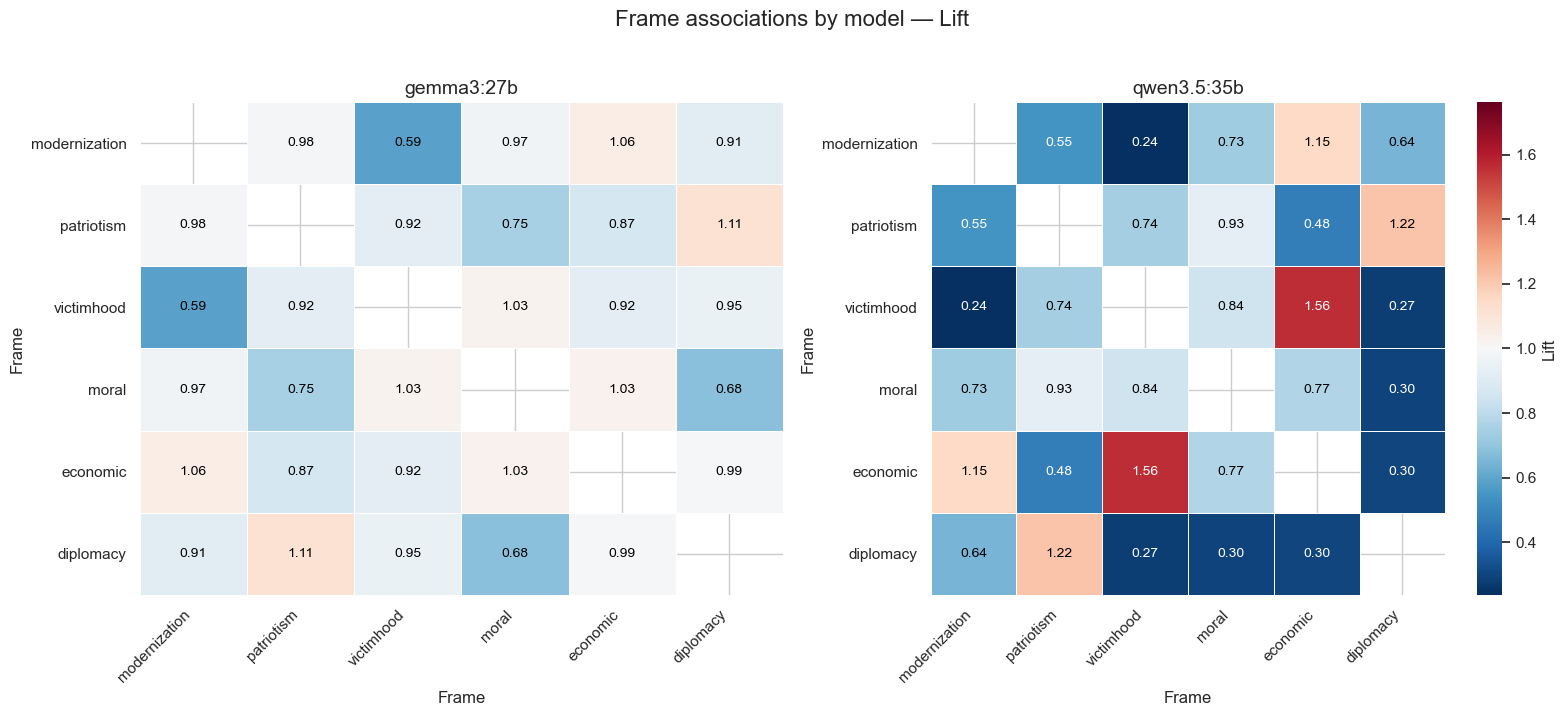

In [119]:
# ============================================================
# LIFT BY MODEL
# SIDE-BY-SIDE HEATMAPS
# ============================================================

models_to_plot = [
    model
    for model in MODEL_ORDER
    if model in lift_by_model
]


# ------------------------------------------------------------
# Prepare matrices and remove diagonal
# ------------------------------------------------------------

lift_plot_by_model = {}

for model in models_to_plot:

    matrix = (
        lift_by_model[model]
        .copy()
    )

    np.fill_diagonal(
        matrix.values,
        np.nan
    )

    lift_plot_by_model[
        model
    ] = matrix


# ------------------------------------------------------------
# Common symmetric scale around Lift = 1
# ------------------------------------------------------------

global_deviation = max(

    np.nanmax(
        np.abs(
            matrix.to_numpy() - 1
        )
    )

    for matrix
    in lift_plot_by_model.values()
)

vmin = max(
    0,
    1 - global_deviation
)

vmax = (
    1 + global_deviation
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

n_models = len(
    models_to_plot
)

fig, axes = plt.subplots(
    1,
    n_models,
    figsize=(8 * n_models, 7),
    sharey=False,
    squeeze=False
)

axes = axes[0]


for idx, (ax, model) in enumerate(
    zip(
        axes,
        models_to_plot
    )
):

    matrix = (
        lift_plot_by_model[
            model
        ]
    )

    n_rows, n_cols = (
        matrix.shape
    )


    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    sns.heatmap(
        matrix,

        ax=ax,

        cmap="RdBu_r",
        center=1,

        vmin=vmin,
        vmax=vmax,

        annot=False,

        linewidths=0.5,
        linecolor="white",

        xticklabels=False,
        yticklabels=False,

        cbar=(
            idx
            == n_models - 1
        ),

        cbar_kws={
            "label": "Lift"
        } if idx == n_models - 1
        else None
    )


    # --------------------------------------------------------
    # Manual annotations
    # --------------------------------------------------------

    for i in range(n_rows):

        for j in range(n_cols):

            value = matrix.iat[i, j]

            if pd.isna(value):
                continue

            text_color = (
                "white"
                if abs(value - 1)
                > global_deviation * 0.55
                else "black"
            )

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color=text_color,
                zorder=10,
                clip_on=False
            )


    # --------------------------------------------------------
    # Frame labels
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(n_cols)
        + 0.5
    )

    ax.set_xticklabels(
        matrix.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticks(
        np.arange(n_rows)
        + 0.5
    )

    ax.set_yticklabels(
        matrix.index,
        rotation=0
    )

    ax.set_xlim(
        0,
        n_cols
    )

    ax.set_ylim(
        n_rows,
        0
    )

    ax.set_title(
        str(model),
        fontsize=14
    )

    ax.set_xlabel(
        "Frame"
    )

    ax.set_ylabel(
        "Frame"
    )


fig.suptitle(
    "Frame associations by model — Lift",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

The three measures now answer complementary questions: co-occurrence count tells you which pairs occur together most often; Jaccard tells you how much the two frames overlap relative to their union; lift tells you whether that overlap is greater or smaller than expected from their individual prevalence.

## Export summary tables

Save the key aggregate tables to CSV for use outside the notebook (e.g. in a paper or report).


In [62]:

OUT_DIR = Path("./analysis_outputs")
OUT_DIR.mkdir(exist_ok=True)

label_counts.to_csv(OUT_DIR / "frame_label_counts_by_model.csv")
label_props.to_csv(OUT_DIR / "frame_label_shares_by_model.csv")
type_counts.to_csv(OUT_DIR / "frame_type_counts_by_model.csv")
type_counts_agg.to_csv(OUT_DIR / "frame_type_counts_aggregate.csv")
name_counts.to_csv(OUT_DIR / "frame_name_counts_by_model.csv")
name_counts_agg.to_csv(OUT_DIR / "frame_name_counts_aggregate.csv")
pol_counts.to_csv(OUT_DIR / "polarity_counts_by_model_and_frame.csv")
polarity_agg.to_csv(OUT_DIR / "polarity_counts_aggregate.csv")

print(f"Saved summary tables to {OUT_DIR.resolve()}:")
for f in sorted(OUT_DIR.glob("*.csv")):
    print(" ", f.name)


Saved summary tables to /Users/carmand/Desktop/v24/framing_optimized/output/analysis_outputs:
  frame_label_counts_by_model.csv
  frame_label_shares_by_model.csv
  frame_name_counts_aggregate.csv
  frame_name_counts_by_model.csv
  frame_type_counts_aggregate.csv
  frame_type_counts_by_model.csv
  polarity_counts_aggregate.csv
  polarity_counts_by_model_and_frame.csv
